# Mapping Heat Vulnerability Across Amsterdam
### An integrated index for prioritising urban cooling interventions

*Computational Social Science — group project*

---

## 1. Introduction

Heatwaves are the deadliest climate hazard in the Netherlands, and Amsterdam is
warming faster than the surrounding countryside because of the **urban heat-island
(UHI) effect**: dark, sealed surfaces absorb solar radiation during the day and
release it slowly at night, while a lack of vegetation and water removes the natural
cooling that evapotranspiration and shade would otherwise provide. The 2019 and 2022
heatwaves both produced measurable excess mortality, concentrated among elderly and
socially isolated residents.

Following the IPCC framing, **heat risk is not the same as heat exposure**. Risk is the
interaction of a *hazard* (high temperatures), the *exposure* of people to that hazard,
and their *vulnerability* — which combines **sensitivity** (who is harmed most, e.g. the
elderly, the chronically ill, low-income and socially isolated residents) and
**adaptive capacity** (whether people can escape the heat: access to green space, water,
and public cooled spaces). Two neighbourhoods can be equally hot while facing very
different risk, because their populations and their access to relief differ.

The City of Amsterdam already publishes climate-risk maps and a community-facing
"koeltekaart" (cooling map). What is missing is an **integrated, neighbourhood-level
prioritisation**: a single, defensible ranking that tells policymakers *where the people
most vulnerable to heat also have the least access to cooling*, and *which interventions
would deliver the most benefit*. That is the gap this project addresses.

### Research questions

1. **RQ1 — Drivers.** Which physical-environmental characteristics of a neighbourhood
   (impervious surface, public/private greenery, surface water, tree canopy) explain its
   heat risk?
2. **RQ2 — Double disadvantage.** Are socially vulnerable neighbourhoods also the ones
   with the *poorest* access to cooling infrastructure, and does this gap widen for the
   most vulnerable?
3. **RQ3 — Composite index.** Can we combine heat exposure, social vulnerability and
   cooling access into a single, statistically robust **Heat Vulnerability Index (HVI)**
   that tiers neighbourhoods for action?
4. **RQ4 — Where to act.** Where are the statistically significant heat-vulnerability
   *clusters*, and which neighbourhoods offer the greatest return on cooling
   investment (the "green deserts" that need both trees and shelters)?

### Approach in one paragraph

We assemble a neighbourhood (*buurt*) level dataset from official open sources, engineer
the physical and social features described above, and answer each research question with
an appropriate method — robust OLS regression for the drivers, a standardised additive
index for social vulnerability, quantile regression for the access gap, a weighted
composite for the HVI (with bootstrap and weight-sensitivity checks), and local spatial
autocorrelation (Moran's *I* / LISA) to locate clusters. The outputs feed a policy
dashboard.

### Update notes

This version resolves the merge-conflict markers that made the uploaded notebook invalid JSON and applies statistical-analysis fixes: corrected Q-Q reference lines, VIF calculation with an intercept, Fisher-Jenks bootstrapping consistent with the tiering method, FDR correction for local Moran/LISA tests, and more cautious wording around convergent validity against `HI_TOTAAL`. Outputs were cleared because the source data files were not included with the upload, so the notebook should be rerun in the project repository.


---
## 2. Environment & configuration

The analysis uses the standard scientific-Python stack plus `geopandas`/`libpysal`/`esda`
for the spatial work. All packages are pinned in `requirements.txt`; from a clean
environment:

```bash
pip install -r requirements.txt
```

The notebook resolves the repository root automatically, so it runs unchanged whether it
is launched from the repo root or from the `Data_analysis/` folder. Unless extra packages installation is required.

In [1]:
import json, re, unicodedata, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as scs
from scipy.stats import pearsonr, spearmanr, shapiro, normaltest, jarque_bera, probplot, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.multitest import multipletests
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import mapclassify

warnings.filterwarnings("ignore")           # silence benign geopandas/statsmodels notes
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 10})

# Amsterdam Design System palette (so figures match the city's house style)
AMS_BLUE, AMS_RED, AMS_GREEN = "#004699", "#ec0000", "#00893c"
AMS_ORANGE, AMS_INFO, AMS_PURPLE = "#ff9100", "#009de6", "#a00078"

# Resolve repository root (folder that contains both data/ and Data_analysis/)
            "source": [
                "import json\n",
                "import re\n",
                "import time\n",
                "from typing import Any\n",
                "\n",
                "import requests\n",
                "\n",
                "\n",
                "def extract_rows(payload: dict[str, Any]) -> list[dict[str, Any]]:\n",
                "    embedded = payload.get(\"_embedded\", {})\n",
                "    rows = embedded.get(\"stamgegevens\")\n",
                "    if isinstance(rows, list):\n",
                "        return rows\n",
                "    for value in embedded.values():\n",
                "        if isinstance(value, list):\n",
                "            return value\n",
                "    return []\n",
                "\n",
                "\n",
                "def camel_to_snake(name: str) -> str:\n",
                "    return re.sub(r\"(?<!^)(?=[A-Z])\", \"_\", name).lower()\n",
                "\n",
                "\n",
                "def normalize_tree_rows(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:\n",
                "    normalized: list[dict[str, Any]] = []\n",
                "    for row in rows:\n",
                "        if not isinstance(row, dict):\n",
                "            continue\n",
                "        if row.get(\"properties\") and row.get(\"geometry\"):\n",
                "            normalized.append(row)\n",
                "            continue\n",
                "        geometry = row.get(\"geometrie\") or row.get(\"geometry\")\n",
                "        properties = {}\n",
                "        for key, value in row.items():\n",
                "            if key in {\"geometrie\", \"geometry\"}:\n",
                "                continue\n",
                "            properties[camel_to_snake(key)] = value\n",
                "        normalized.append({\"type\": \"Feature\", \"properties\": properties, \"geometry\": geometry})\n",
                "    return normalized\n",
                "\n",
                "\n",
                "def load_amsterdam_trees(cache_path, base_url=\"https://api.data.amsterdam.nl/v1/bomen/stamgegevens/\", page_size=1000):\n",
                "    if cache_path.exists():\n",
                "        with cache_path.open(\"r\", encoding=\"utf-8\") as f:\n",
                "            cached = json.load(f)\n",
                "        return normalize_tree_rows(cached)\n",
                "\n",
                "    session = requests.Session()\n",
                "    headers = {\"Accept\": \"application/hal+json\"}\n",
                "    params: dict[str, Any] = {\"_format\": \"json\", \"_pageSize\": page_size, \"page\": 1}\n",
                "    all_rows: list[dict[str, Any]] = []\n",
                "\n",
                "    while True:\n",
                "        response = session.get(base_url, params=params, headers=headers, timeout=120)\n",
                "        response.raise_for_status()\n",
                "        payload = response.json()\n",
                "        rows = extract_rows(payload)\n",
                "        all_rows.extend(rows)\n",
                "        print(f\"page {params['page']}: {len(rows)} rows; total={len(all_rows)}\")\n",
                "\n",
                "        next_link = payload.get(\"_links\", {}).get(\"next\", {}).get(\"href\")\n",
                "        if not next_link:\n",
                "            break\n",
                "        params[\"page\"] += 1\n",
                "        time.sleep(0.2)\n",
                "\n",
                "    trees_out = normalize_tree_rows(all_rows)\n",
                "    with cache_path.open(\"w\", encoding=\"utf-8\") as f:\n",
                "        json.dump(trees_out, f, ensure_ascii=False)\n",
                "\n",
                "    print(f\"Saved {cache_path.resolve()} with {len(trees_out)} rows\")\n",
                "    return trees_out\n",
                "\n",
                "\n",
                "trees = load_amsterdam_trees(INPUTS / \"trees_raw.json\")\n",
                "tp = pd.DataFrame([{**t[\"properties\"],\n",
                "                    \"x\": t[\"geometry\"][\"coordinates\"][0],\n",
                "                    \"y\": t[\"geometry\"][\"coordinates\"][1]}\n",
                "                   for t in trees\n",
                "                   if t.get(\"geometry\") and t[\"geometry\"].get(\"coordinates\")])\n",

| Dataset | Source | Granularity | What we use it for | Reproduced here? |
|---|---|---|---|---|
| **CBS Kerncijfers wijken en buurten 2022** | Statistics Netherlands (CBS), via the PDOK *buurten* WFS in QGIS | buurt | Demographics, income, housing, amenity distances → social vulnerability & cooling-access proxy | Loaded from `ams_features.csv` (CBS columns documented below) |
| **Surface temperature (LST)** | Landsat 8 Collection-2 L2 (`LANDSAT/LC08/C02/T1_L2`), summer median 2023, band `ST_B10`, via Google Earth Engine | 30 m raster → buurt mean | Heat exposure (`temp_mean`) | Documented (GEE script in appendix); zonal mean precomputed into `ams_features.csv` |
| **NDVI (greenness)** | Landsat 8, same GEE composite | 30 m raster → buurt mean | Vegetation cover (`ndvi_mean`) | Documented; precomputed |
| **Water / road surface share** | PDOK BGT `waterdeel` & `wegdeel` WFS, intersected with buurten in QGIS | buurt | Physical drivers (`water_prc`, `road_prc`) | Documented (WFS service, not a saved file) |
| **Climate-risk scores** | Gemeente Amsterdam *Klimaatrisicokaarten* (Klimaateffectatlas), heat module | buurt | Official heat-risk index `HI_TOTAAL_S.0` and its drought (`DR_`) drivers | Loaded from `climate_risk_scores.csv` |
| **Street trees** | Gemeente Amsterdam open data — *Bomen* (≈322k individual trees, RD-New coordinates) | point | Tree density, maturity, species richness | **Yes** — spatial-joined here from `trees_raw.json` |
| **Cooling locations (koelteplekken)** | Project-curated list of public cooled/water spots | point (12) | Gap analysis: which vulnerable buurten lack a nearby shelter | **Yes** — from `data/koeltekaart_data.csv` |
| **Buurt boundaries** | CBS/PDOK *Wijk- en buurtkaart 2022* | polygon | Spatial join, centroids, contiguity weights, mapping | **Yes** — geometry from `buurten_geometry.geojson` |

> **A note on `ams_features.csv`.** This table is our group's feature build: the CBS 2022
> *Kerncijfers* joined with the GEE/PDOK raster-derived columns above. Because the GEE and
> PDOK layers were produced through interactive services (not saved files), this notebook
> treats `ams_features.csv` as a documented upstream input rather than rebuilding the
> remote-sensing extraction. Everything *downstream* of it — the joins, the tree
> aggregation, every index and model — is reproduced from scratch below.

Repository root: C:\Users\alvah\Documents\koeltekaart-amsterdam


In [3]:
# ---- 3.1 Base feature table (CBS 2022 + GEE/PDOK spatial layers) ----------
ams = pd.read_csv(INPUTS / "ams_features.csv", low_memory=False)
for c in ams.select_dtypes("number").columns:
    ams[c] = clean_cbs(ams[c])
ams["key"] = ams["buurtnaam"].map(norm_name)
df = ams.copy()
print(f"Loaded ams_features: {df.shape[0]} buurten x {df.shape[1]} columns")
print(f"Temperature range: {df.temp_mean.min():.1f}-{df.temp_mean.max():.1f} C "
      f"(mean {df.temp_mean.mean():.1f} C)")

Loaded ams_features: 481 buurten x 208 columns
Temperature range: 21.7-41.5 C (mean 35.4 C)


In [ ]:
# ---- 3.2 Buurt boundaries (geometry only) --------------------------------
geo = gpd.read_file(INPUTS / "buurten_geometry.geojson")[["buurtnaam", "geometry"]].copy()
geo["key"] = geo["buurtnaam"].map(norm_name)
geo = geo.dissolve(by="key", as_index=False)               # one polygon per buurt
geo = geo.set_crs(4326, allow_override=True).to_crs(28992)  # RD-New (metres)
matched = geo["key"].isin(df["key"]).sum()
print(f"Buurt polygons: {len(geo)} (matched to features: {matched}/{df['key'].nunique()})")

Buurt polygons: 498 (matched to features: 477/480)


In [5]:
# ---- 3.3 Official climate-risk (heat) scores -----------------------------
crd = pd.read_csv(INPUTS / "climate_risk_scores.csv", low_memory=False)
for c in crd.select_dtypes("number").columns:
    crd[c] = clean_cbs(crd[c])

# The risk table prefixes names with "RK_"; strip it, then normalise.
crd["key"] = crd["name"].str.replace(r"^RK_", "", regex=True).map(norm_name)
risk_cols = [c for c in crd.columns if c.split("_")[0] in ("HI", "DR", "WO", "AA")]

# Exact key join, with a conservative fuzzy fallback for the few residual spellings.
import difflib
ams_keys = df["key"].tolist()
def resolve_key(k):
    if k in set(ams_keys):
        return k
    hit = difflib.get_close_matches(k, ams_keys, n=1, cutoff=0.88)
    return hit[0] if hit else None

crd["key"] = crd["key"].map(resolve_key)
n_unmatched = crd["key"].isna().sum()
crd_buurt = crd.dropna(subset=["key"]).groupby("key")[risk_cols].mean().reset_index()
df = df.merge(crd_buurt, on="key", how="left")

cov = df["HI_TOTAAL_S.0"].notna().sum()
print(f"Climate-risk scores merged on {len(risk_cols)} columns.")
print(f"HI_TOTAAL_S.0 coverage: {cov}/{len(df)} buurten ({cov/len(df)*100:.1f}%)")
print(f"Risk records with no Amsterdam buurt match: {n_unmatched} "
      f"(these are former Weesp neighbourhoods, outside the CBS Amsterdam buurt set)")

Climate-risk scores merged on 96 columns.
HI_TOTAAL_S.0 coverage: 479/481 buurten (99.6%)
Risk records with no Amsterdam buurt match: 19 (these are former Weesp neighbourhoods, outside the CBS Amsterdam buurt set)


---
## 4. Tree canopy (feature engineering)

Street trees are the single most cost-effective cooling intervention a city controls, so we
want a per-buurt measure of canopy. The open-data tree register gives ~322,000 individual
trees as points in the Dutch **RD-New** coordinate system (EPSG:28992).

**Method.** Rather than relying on the trees' own (inconsistently named) buurt labels, we
perform a **spatial join**: each tree point is assigned to the buurt polygon that contains
it. This is geometrically exact and independent of naming. We then derive, per buurt:

- `tree_count` and `tree_density_per_km2` — canopy quantity, area-normalised;
- `pct_mature` — share of trees ≥12 m tall (mapped from the height class), since mature
  canopy delivers far more shade and evapotranspiration than saplings;
- `tree_species_richness` — a simple resilience proxy (monocultures are vulnerable to
  disease, e.g. Dutch elm).

In [9]:
from pathlib import Path
import json
import time
from typing import Any

import numpy as np
import pandas as pd
import geopandas as gpd
import requests


def extract_rows(payload: dict[str, Any]) -> list[dict[str, Any]]:
    embedded = payload.get("_embedded", {})
    rows = embedded.get("stamgegevens")
    if isinstance(rows, list):
        return rows

    for value in embedded.values():
        if isinstance(value, list):
            return value

    return []


def load_amsterdam_trees(
    cache_path: Path,
    base_url: str = "https://api.data.amsterdam.nl/v1/bomen/stamgegevens/",
    page_size: int = 1000,
    api_key: str | None = None,
) -> list[dict[str, Any]]:
    cache_path = Path(cache_path)

    if cache_path.exists():
        with cache_path.open("r", encoding="utf-8") as f:
            return json.load(f)

    cache_path.parent.mkdir(parents=True, exist_ok=True)

    session = requests.Session()
    headers = {
        "Accept": "application/hal+json",
        # Keep geometry in Dutch RD New / EPSG:28992 when supported
        "Accept-Crs": "EPSG:28992",
    }

    if api_key:
        headers["X-Api-Key"] = api_key

    all_rows: list[dict[str, Any]] = []
    last_id: int | None = None
    batch = 1

    while True:
        params: dict[str, Any] = {
            "_format": "json",
            "_pageSize": page_size,
            "_sort": "id",
            # reduce payload; add more fields here if needed
            "_fields": "id,geometrie,boomhoogteklasseActueel,soortnaamTop",
        }

        if last_id is not None:
            params["id[gt]"] = last_id

        response = session.get(base_url, params=params, headers=headers, timeout=120)

        if response.status_code == 403:
            raise RuntimeError(
                "Amsterdam API returned 403. This often happens with deep pagination "
                "or when an API key is required. This loader avoids deep pagination, "
                "but if you still get 403, request an Amsterdam API key and pass it as api_key."
            )

        response.raise_for_status()
        payload = response.json()
        rows = extract_rows(payload)

        if not rows:
            break

        rows = [r for r in rows if r.get("id") is not None]
        rows = sorted(rows, key=lambda r: int(r["id"]))

        all_rows.extend(rows)

        new_last_id = int(rows[-1]["id"])
        print(f"batch {batch}: {len(rows)} rows; total={len(all_rows)}; last_id={new_last_id}")

        if len(rows) < page_size:
            break

        if last_id == new_last_id:
            raise RuntimeError("Pagination stalled: last_id did not advance.")

        last_id = new_last_id
        batch += 1
        time.sleep(0.2)

    with cache_path.open("w", encoding="utf-8") as f:
        json.dump(all_rows, f, ensure_ascii=False)

    print(f"Saved {cache_path.resolve()} with {len(all_rows)} rows")
    return all_rows


def trees_to_gdf(trees_raw: list[dict[str, Any]]) -> gpd.GeoDataFrame:
    records = []

    for row in trees_raw:
        geom = row.get("geometrie") or row.get("geometry")
        if not isinstance(geom, dict):
            continue

        coords = geom.get("coordinates")
        if not coords or len(coords) < 2:
            continue

        rec = {
            "id": row.get("id"),
            "boomhoogteklasseActueel": row.get("boomhoogteklasseActueel"),
            "soortnaamTop": row.get("soortnaamTop"),
            "x": coords[0],
            "y": coords[1],
        }
        records.append(rec)

    tp = pd.DataFrame(records)

    if tp.empty:
        raise ValueError("No valid tree geometries found in API response.")

    return gpd.GeoDataFrame(
        tp,
        geometry=gpd.points_from_xy(tp["x"], tp["y"]),
        crs=28992,
    )


# Paths
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

INPUTS = REPO_ROOT / "data"
DATA = REPO_ROOT / "data"
OUT = REPO_ROOT / "Data_analysis" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)


# Load trees
trees_raw = load_amsterdam_trees(INPUTS / "trees_raw.json")
tg = trees_to_gdf(trees_raw)


HEIGHT_M = {
    "a. tot 6 m.": 3.0,
    "b. 6 tot 9 m.": 7.5,
    "c. 9 tot 12 m.": 10.5,
    "d. 12 tot 15 m.": 13.5,
    "e. 15 tot 18 m.": 16.5,
    "f. 18 tot 24 m.": 21.0,
    "g. 24 m. en hoger": 26.0,
}

MATURE = {
    "d. 12 tot 15 m.",
    "e. 15 tot 18 m.",
    "f. 18 tot 24 m.",
    "g. 24 m. en hoger",
}

tg["height_m"] = tg["boomhoogteklasseActueel"].map(HEIGHT_M)
tg["is_mature"] = tg["boomhoogteklasseActueel"].isin(MATURE)


joined = gpd.sjoin(
    tg,
    geo[["key", "geometry"]],
    how="inner",
    predicate="within",
)

tree_agg = (
    joined.groupby("key")
    .agg(
        tree_count=("id", "count"),
        pct_mature=("is_mature", "mean"),
        mean_height_m=("height_m", "mean"),
        tree_species_richness=("soortnaamTop", lambda x: x.dropna().nunique()),
    )
    .reset_index()
)

tree_agg["pct_mature"] = (tree_agg["pct_mature"] * 100).round(1)

df = df.merge(tree_agg, on="key", how="left")

df["tree_density_per_km2"] = (
    df["tree_count"] / (df["buurt_area"] / 1e6)
).round(1)

placed_pct = len(joined) / len(tg) * 100 if len(tg) else 0

print(
    f"Trees placed by spatial join: {len(joined):,}/{len(tg):,} "
    f"({placed_pct:.1f}%)"
)
print(f"Buurten with tree data: {df['tree_count'].notna().sum()}/{len(df)}")
print(
    f"Tree density: median {df.tree_density_per_km2.median():.0f}, "
    f"mean {df.tree_density_per_km2.mean():.0f} trees/km2"
)


batch 1: 1000 rows; total=1000; last_id=920969
batch 2: 1000 rows; total=2000; last_id=922039
batch 3: 1000 rows; total=3000; last_id=923076
batch 4: 1000 rows; total=4000; last_id=924112
batch 5: 1000 rows; total=5000; last_id=925155
batch 6: 1000 rows; total=6000; last_id=926185
batch 7: 1000 rows; total=7000; last_id=927255
batch 8: 1000 rows; total=8000; last_id=928298
batch 9: 1000 rows; total=9000; last_id=929332
batch 10: 1000 rows; total=10000; last_id=930377
batch 11: 1000 rows; total=11000; last_id=931427
batch 12: 1000 rows; total=12000; last_id=932448
batch 13: 1000 rows; total=13000; last_id=933499
batch 14: 1000 rows; total=14000; last_id=934631
batch 15: 1000 rows; total=15000; last_id=935698
batch 16: 1000 rows; total=16000; last_id=936731
batch 17: 1000 rows; total=17000; last_id=937764
batch 18: 1000 rows; total=18000; last_id=938791
batch 19: 1000 rows; total=19000; last_id=939830
batch 20: 1000 rows; total=20000; last_id=940858
batch 21: 1000 rows; total=21000; last

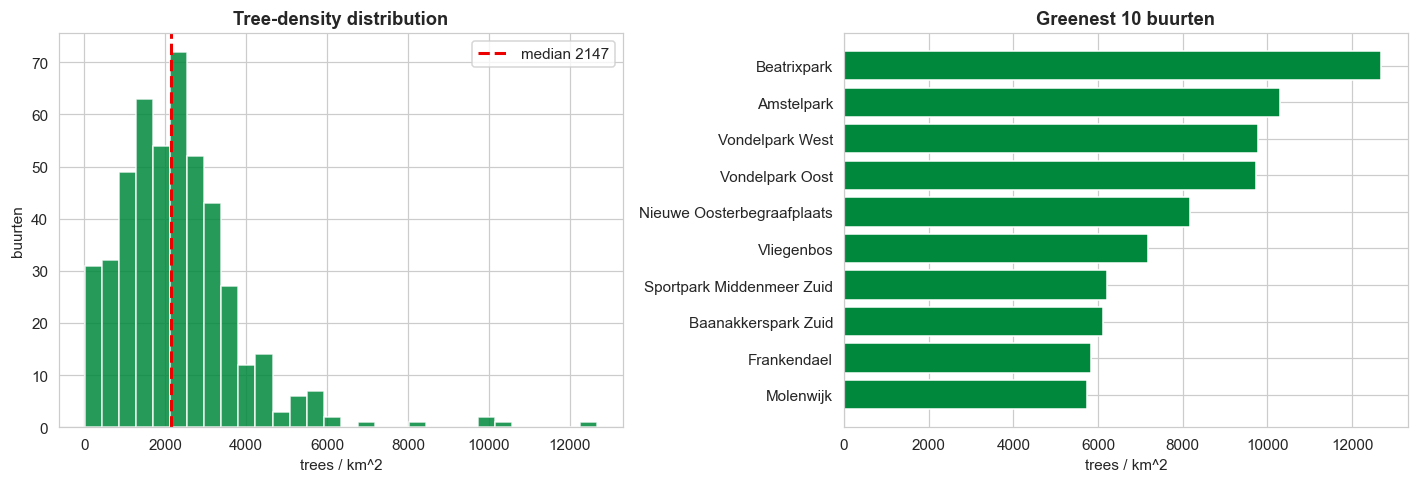

Low-canopy buurten (<500 trees/km^2): 38


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
d = df["tree_density_per_km2"].dropna()
ax[0].hist(d, bins=30, color=AMS_GREEN, alpha=0.85, edgecolor="white")
ax[0].axvline(d.median(), color=AMS_RED, ls="--", lw=2, label=f"median {d.median():.0f}")
ax[0].set(xlabel="trees / km^2", ylabel="buurten", title="Tree-density distribution")
ax[0].legend()
top = df.nlargest(10, "tree_density_per_km2")[["buurtnaam", "tree_density_per_km2"]].dropna()
ax[1].barh(top.buurtnaam, top.tree_density_per_km2, color=AMS_GREEN)
ax[1].invert_yaxis(); ax[1].set(xlabel="trees / km^2", title="Greenest 10 buurten")
plt.tight_layout(); plt.savefig(OUT / "fig_tree_density.png", bbox_inches="tight"); plt.show()
print("Low-canopy buurten (<500 trees/km^2):", int((df.tree_density_per_km2 < 500).sum()))

---
## 5. Cooling access (feature engineering)

"Adaptive capacity" needs an operational measure of how easily residents can reach relief
from heat. Amsterdam has only **twelve** officially designated cooling shelters — far too
few to score adaptive capacity for all 481 neighbourhoods — so we proxy it with two
complementary ingredients.

**(a) Refuge access (distance-based).** We invert and normalise the CBS average distance to
eight amenity types that are reliably air-conditioned, water-based or otherwise cool and are
densely distributed across the city: a **swimming pool**, **public library**, **large
supermarket**, **department store**, **cinema**, **museum**, **theatre** and **ice rink**.
Closer = better access. These match the dominant categories in the official koelteplek list
(libraries, supermarkets, water/leisure sites) while widening coverage. We deliberately
exclude cafés/restaurants (not refuges), train stations (transit, not shelter) and
saunas/tanning studios (hot).

**(b) Private adaptive capacity.** We add the Hittestresskaart's own *access-to-garden*
score (`HI_AV_TOEGANG_TOT_TUIN`), a direct measure of private cooling capacity. Because we
no longer use the composite `HI_TOTAAL` anywhere in the index, this indicator is counted
exactly once.

The eight refuge distances and the garden score are averaged into a single 0–1
`cooling_access` index (higher = better access). Separately we compute the real distance
from each buurt centroid to the nearest of the twelve official koelteplekken
(`dist_koelteplek_m`) and keep it **only as a shelter-gap diagnostic** — it is too sparse to
score every neighbourhood, so it does not enter the index.

In [11]:
def norm01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0 + 0.5

# (a) Cooling-access proxy = access to cool / air-conditioned public refuges,
#     plus one measure of PRIVATE adaptive capacity. Amsterdam has only twelve
#     official cooling shelters, far too few to score 481 buurten, so we proxy
#     adaptive capacity with the CBS average distances to spaces that actually
#     serve as heat refuges. Distances are inverted so HIGHER = better access.
#     We deliberately exclude cafes/restaurants (not refuges), train stations
#     (transit, not shelter) and saunas/tanning studios (hot).
refuge_dist = [v for v in [
    "zwembadGemiddeldeAfstandInKm",          # swimming pool (water-based)
    "bibliotheekGemiddeldeAfstandInKm",      # public library (cooled, free)
    "groteSupermarktGemiddeldeAfstandInKm",  # large supermarket (air-conditioned)
    "warenhuisGemiddeldeAfstandInKm",        # department store (air-conditioned)
    "bioscoopGemiddeldeAfstandInKm",         # cinema (air-conditioned)
    "gemiddeldeAfstandTotMuseum",            # museum (cooled, often free entry)
    "theaterGemiddeldeAfstandInKm",          # theatre (air-conditioned)
    "kunstijsbaanGemiddeldeAfstandInKm",     # ice rink (actively cold)
] if v in df]
access = (1 - df[refuge_dist].apply(norm01))           # closer = better access

# Private adaptive capacity: the Hittestresskaart's own access-to-garden score.
# Because we no longer use the composite HI_TOTAAL anywhere, this is counted once.
adapt = [v for v in ["HI_AV_TOEGANG_TOT_TUIN_S.0"] if v in df]
access_all = pd.concat([access, df[adapt].apply(norm01)], axis=1) if adapt else access

df["cooling_access"] = access_all.mean(axis=1)          # 0-1, higher = better access
print(f"Cooling-access index from {access_all.shape[1]} indicators:")
print("  refuge distances :", refuge_dist)
print("  private capacity :", adapt)
print(f"  mean {df.cooling_access.mean():.3f}; coverage "
      f"{df.cooling_access.notna().sum()}/{len(df)} "
      f"(the {df.cooling_access.isna().sum()} without data are non-residential: "
      f"parks, harbours, cemeteries, empty new islands)")

# (b) real distance to nearest official koelteplek - kept ONLY as a shelter-gap
#     diagnostic (too sparse to score every buurt, so it does not enter the index)
koel = pd.read_csv(DATA / "koeltekaart_data.csv").dropna(subset=["latitude", "longitude"])
kg = gpd.GeoDataFrame(koel, geometry=gpd.points_from_xy(koel.longitude, koel.latitude),
                      crs=4326).to_crs(28992)
cent = geo.copy(); cent["geometry"] = cent.geometry.centroid
cent["dist_koelteplek_m"] = cent.geometry.apply(lambda p: float(kg.distance(p).min()))
df = df.merge(cent[["key", "dist_koelteplek_m"]], on="key", how="left")
print(f"\nOfficial koelteplekken: {len(kg)}")
print(f"  median buurt->nearest shelter: {df.dist_koelteplek_m.median():.0f} m")
print(f"  buurten within a 500 m walk of a shelter: {(df.dist_koelteplek_m<=500).sum()}")

Cooling-access index from 9 indicators:
  refuge distances : ['zwembadGemiddeldeAfstandInKm', 'bibliotheekGemiddeldeAfstandInKm', 'groteSupermarktGemiddeldeAfstandInKm', 'warenhuisGemiddeldeAfstandInKm', 'bioscoopGemiddeldeAfstandInKm', 'gemiddeldeAfstandTotMuseum', 'theaterGemiddeldeAfstandInKm', 'kunstijsbaanGemiddeldeAfstandInKm']
  private capacity : ['HI_AV_TOEGANG_TOT_TUIN_S.0']
  mean 0.725; coverage 479/481 (the 2 without data are non-residential: parks, harbours, cemeteries, empty new islands)

Official koelteplekken: 12
  median buurt->nearest shelter: 2097 m
  buurten within a 500 m walk of a shelter: 35


---
## 6. Exploratory data analysis

Before modelling we characterise the variables that feed the research questions, grouped
into **physical**, **social** and **cooling/policy** blocks. We check distributions,
normality, outliers, pairwise association and multicollinearity, because these determine
which statistical methods are valid (e.g. whether to trust Pearson vs. Spearman, and
whether the regression standard errors need to be robust).

In [12]:
PHYS = [v for v in ["temp_mean", "ndvi_mean", "water_prc", "road_prc",
                    "tree_density_per_km2", "HI_BLOOTSTELLING_S.0", "HI_KO_PET_S.0"] if v in df]
SOCIAL = [v for v in ["HI_GEVOELIGHEID_S.0", "percentageEenpersoonshuishoudens",
                      "percentageNietWesterseMigratieachtergrond"] if v in df]
COOL = [v for v in ["cooling_access", "HI_AV_TOEGANG_TOT_TUIN_S.0"] if v in df]
KEY = PHYS + SOCIAL + COOL

desc = df[KEY].describe().T[["count", "mean", "std", "min", "max"]]
desc["skew"] = df[KEY].skew().round(2)
desc["kurtosis"] = df[KEY].kurt().round(2)
desc["missing"] = df[KEY].isna().sum()
print(f"{len(PHYS)} physical, {len(SOCIAL)} social, {len(COOL)} cooling/capacity variables\n")
desc.round(2)

7 physical, 3 social, 2 cooling/capacity variables



,count,mean,std,min,max,skew,kurtosis,missing
temp_mean,481.0,35.39,2.85,21.70,41.51,-1.36,2.67,0
ndvi_mean,481.0,0.39,0.16,-0.28,0.78,-0.30,0.99,0
water_prc,481.0,1.25,2.70,0.00,34.91,5.84,55.08,0
road_prc,479.0,0.12,0.41,0.00,6.10,9.48,115.63,2
tree_density_per_km2,473.0,2290.81,1497.77,2.10,12685.40,1.95,8.57,8
HI_BLOOTSTELLING_S.0,479.0,2.45,0.53,1.00,3.67,-0.27,-0.13,2
HI_KO_PET_S.0,479.0,2.97,0.91,1.00,5.00,-0.02,-0.30,2
HI_GEVOELIGHEID_S.0,479.0,3.02,1.14,1.00,5.00,-0.10,-1.07,2
percentageEenpersoonshuishoudens,440.0,54.74,15.77,8.00,100.00,0.11,0.53,41
percentageNietWesterseMigratieachtergrond,424.0,30.63,20.24,2.00,97.00,0.89,-0.08,57


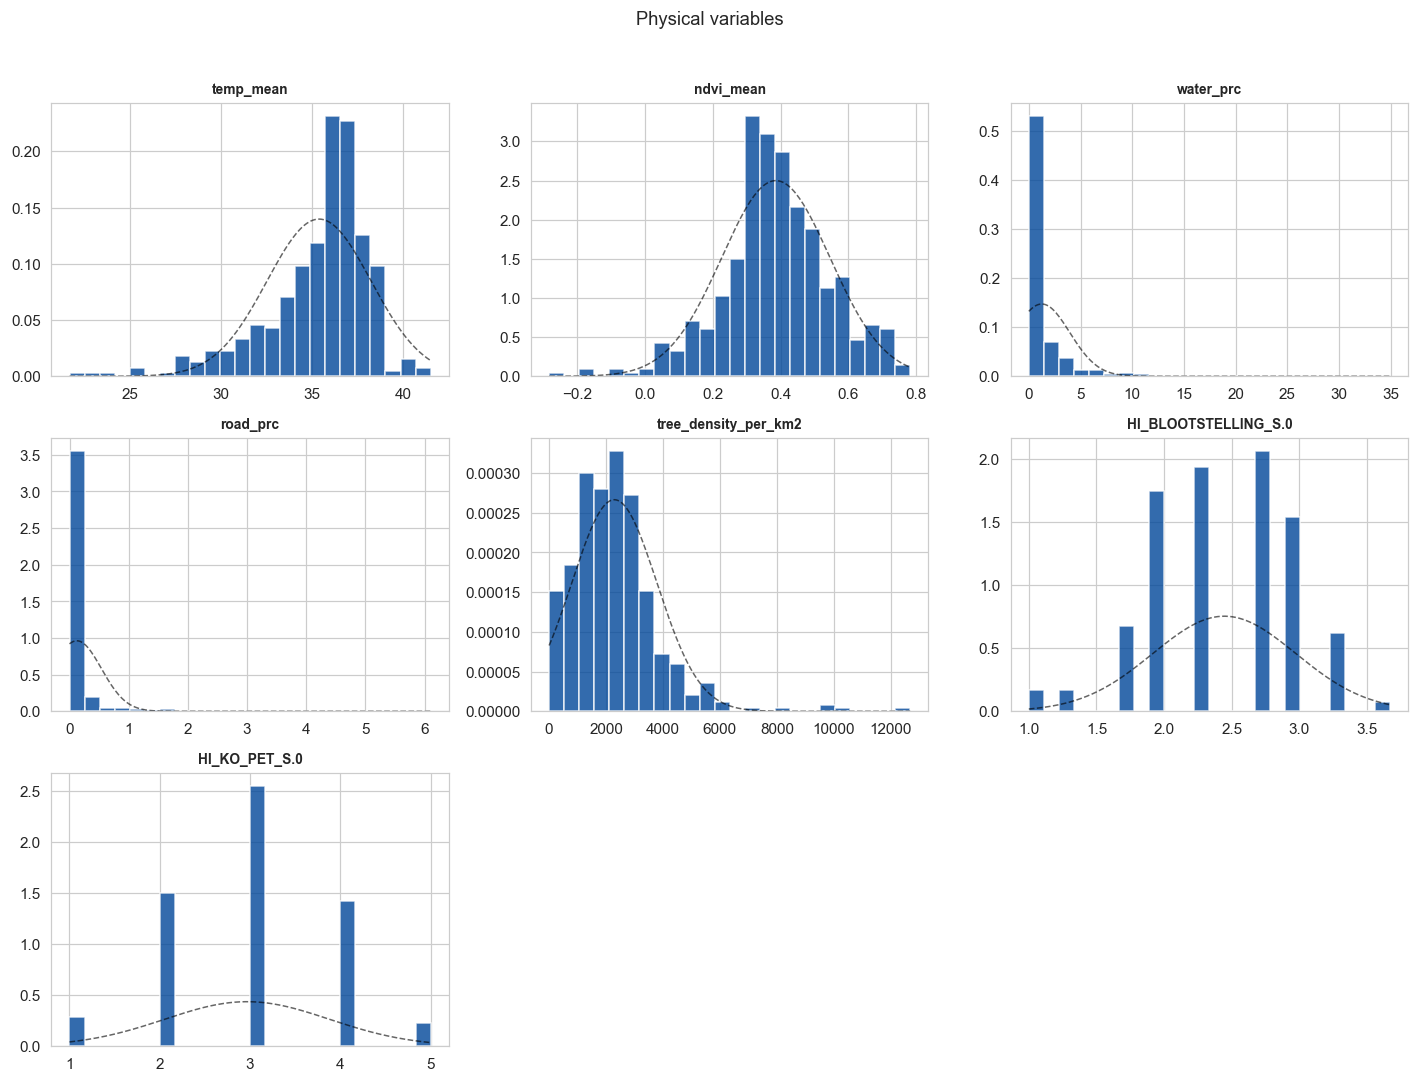

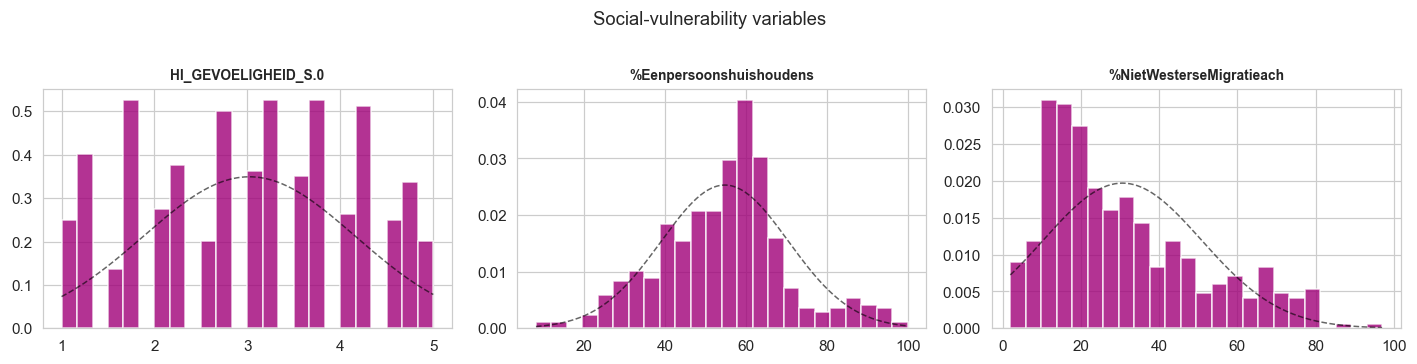

In [13]:
short = lambda v: (v.replace("percentage", "%").replace("Gemiddelde", "")
                    .replace("aantal", "n").replace("InwonersPerKm2", "/km2")[:24])
def hist_block(varlist, title, color):
    n = len(varlist); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow))
    for ax, v in zip(np.ravel(axes), varlist):
        s = df[v].dropna()
        ax.hist(s, bins=24, color=color, alpha=0.8, density=True, edgecolor="white")
        xs = np.linspace(s.min(), s.max(), 200)
        ax.plot(xs, scs.norm.pdf(xs, s.mean(), s.std()), "k--", lw=1, alpha=0.6)
        ax.set_title(short(v), fontsize=9)
    for ax in np.ravel(axes)[n:]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02, fontsize=12); plt.tight_layout()
    plt.savefig(OUT / f"fig_hist_{title.split()[0].lower()}.png", bbox_inches="tight"); plt.show()

hist_block(PHYS, "Physical variables", AMS_BLUE)
hist_block(SOCIAL, "Social-vulnerability variables", AMS_PURPLE)

**Reading the distributions.** Several variables are clearly right-skewed (tree density,
the percentage of low-income households, WMO-care clients) with long upper tails, and the
dashed normal curves fit poorly. This already tells us two things: (i) rank-based
**Spearman** correlations will be safer than Pearson for association testing, and (ii)
ordinary regression standard errors may be unreliable, so we will use
**heteroskedasticity-robust (HC3)** errors. We confirm the non-normality formally next.

In [14]:
rows = []
for v in KEY:
    s = df[v].dropna().values
    if len(s) < 8:
        continue
    sw_p = shapiro(s)[1] if len(s) <= 5000 else np.nan
    rows.append({"variable": short(v), "n": len(s),
                 "Shapiro_p": round(sw_p, 4), "DAgostino_p": round(normaltest(s)[1], 4),
                 "JarqueBera_p": round(jarque_bera(s)[1], 4),
                 "normal@.05": "yes" if (np.nan_to_num(sw_p, nan=1) > .05 and
                                          normaltest(s)[1] > .05) else "no"})
norm_df = pd.DataFrame(rows)
n_norm = (norm_df["normal@.05"] == "yes").sum()
print(f"{n_norm}/{len(norm_df)} variables are normally distributed at alpha=0.05.")
print("-> Non-normality justifies Spearman correlations and HC3-robust regression below.\n")
norm_df

0/12 variables are normally distributed at alpha=0.05.
-> Non-normality justifies Spearman correlations and HC3-robust regression below.



,variable,n,Shapiro_p,DAgostino_p,JarqueBera_p,normal@.05
0,temp_mean,481,0.0,0.0000,0.0000,no
1,ndvi_mean,481,0.0,0.0001,0.0000,no
2,water_prc,481,0.0,0.0000,0.0000,no
3,road_prc,479,0.0,0.0000,0.0000,no
4,tree_density_per_km2,473,0.0,0.0000,0.0000,no
5,HI_BLOOTSTELLING_S.0,479,0.0,0.0440,0.0409,no
6,HI_KO_PET_S.0,479,0.0,0.3127,0.3741,no
7,HI_GEVOELIGHEID_S.0,479,0.0,0.0000,0.0000,no
8,%Eenpersoonshuishoudens,440,0.0,0.0879,0.0577,no
9,%NietWesterseMigratieach,424,0.0,0.0000,0.0000,no


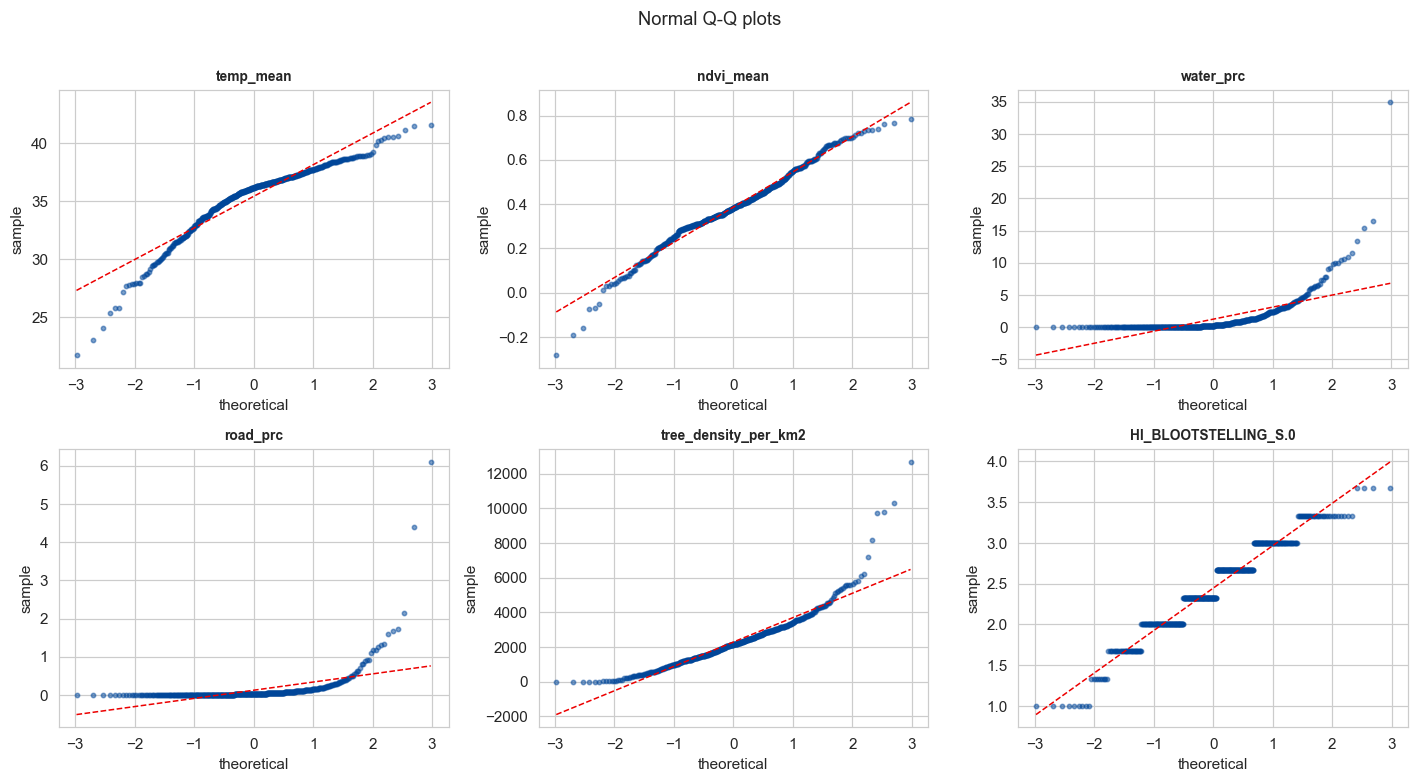

In [15]:
qq_vars = (PHYS + SOCIAL)[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, v in zip(np.ravel(axes), qq_vars):
    (osm, osr), (slope, intercept, r) = probplot(df[v].dropna())
    ax.scatter(osm, osr, s=8, alpha=0.5, color=AMS_BLUE)
    ax.plot(osm, slope * osm + intercept, color=AMS_RED, ls="--", lw=1)
    ax.set_title(short(v), fontsize=9); ax.set_xlabel("theoretical"); ax.set_ylabel("sample")
fig.suptitle("Normal Q-Q plots", y=1.01, fontsize=12); plt.tight_layout()
plt.savefig(OUT / "fig_qq.png", bbox_inches="tight"); plt.show()

### Outlier treatment

Heat-vulnerability data legitimately contains extremes (a port district with almost no
greenery, a leafy villa neighbourhood). We do **not** want to delete these — they are real
and policy-relevant — but we do not want a handful of them to dominate a regression slope.
We flag outliers with a conservative combined rule (outside 3×IQR **or** |z| > 3.5) for
transparency, and **winsorise** the modelling variables at the 1st/99th percentile, which
caps extreme leverage while keeping every neighbourhood in the sample.

In [16]:
flags = pd.DataFrame(index=df.index)
for v in KEY:
    s = df[v].dropna()
    if len(s) < 10:
        continue
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    z = (df[v] - s.mean()) / s.std()
    flags[v] = ((df[v] < q1 - 3*iqr) | (df[v] > q3 + 3*iqr) | (z.abs() > 3.5)).astype(int)
    df[v] = df[v].clip(s.quantile(.01), s.quantile(.99))      # winsorise in place for robust downstream summaries/models
df["n_outlier_flags"] = flags.sum(axis=1)
print("Most outlier-prone variables:")
print(flags.sum().sort_values(ascending=False).head(6).to_string())
print(f"\nBuurten winsorised on >=3 variables: {(df.n_outlier_flags>=3).sum()} "
      f"(kept in sample, extremes capped at 1st/99th pct)")

Most outlier-prone variables:
road_prc                36
water_prc               28
cooling_access          22
temp_mean                6
tree_density_per_km2     5
ndvi_mean                2

Buurten winsorised on >=3 variables: 1 (kept in sample, extremes capped at 1st/99th pct)


### Correlation structure

We inspect both Pearson (linear) and Spearman (rank) correlations. Where they diverge, the
relationship is monotonic but non-linear, and we trust Spearman.

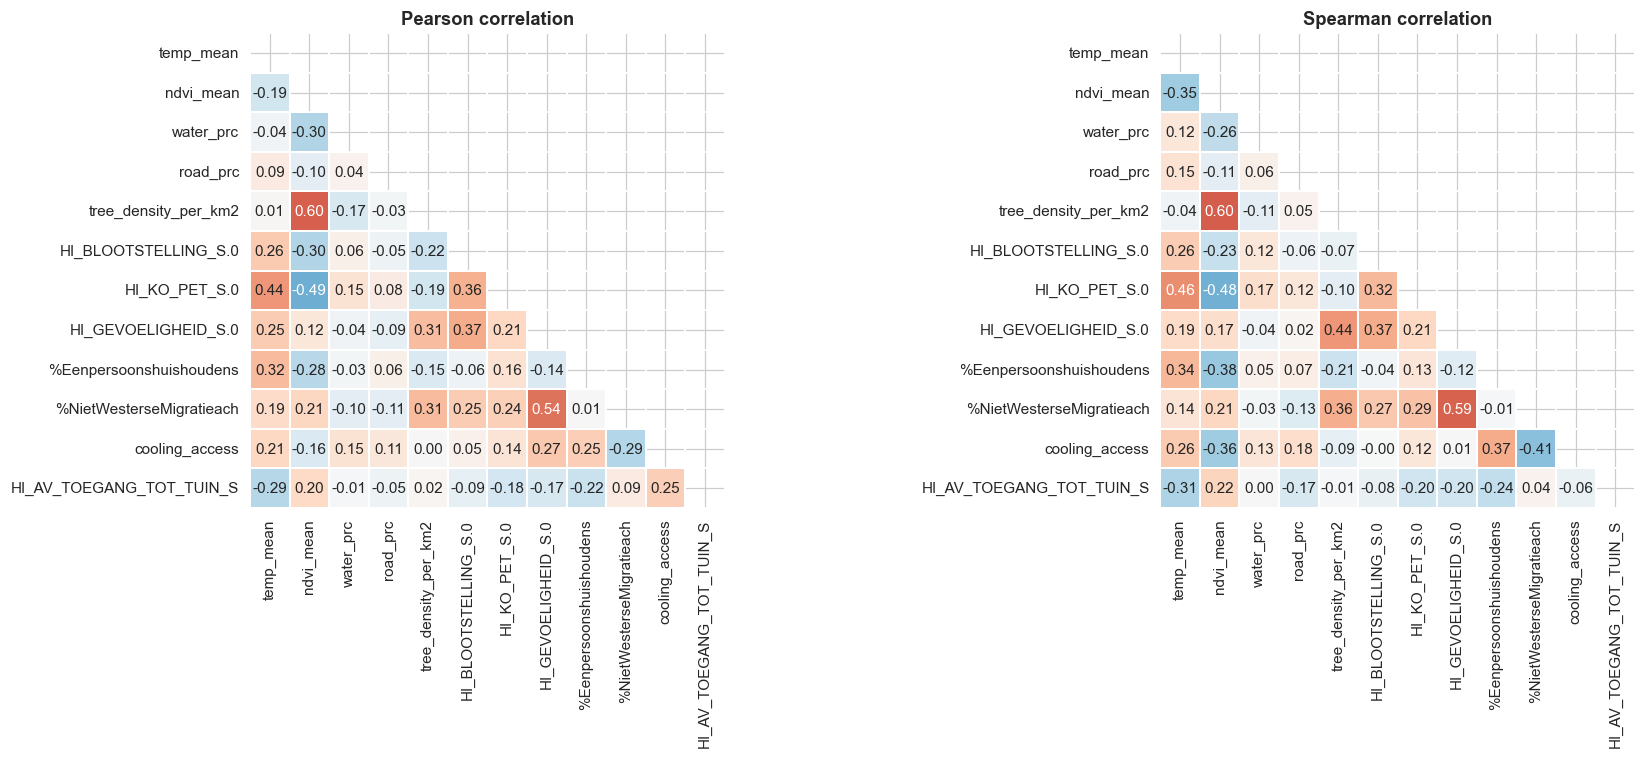

Strongest (Spearman) associations:
  ndvi_mean                x tree_density_per_km2      rho=+0.60
  HI_GEVOELIGHEID_S.0      x %NietWesterseMigratieach  rho=+0.59
  ndvi_mean                x HI_KO_PET_S.0             rho=-0.48
  temp_mean                x HI_KO_PET_S.0             rho=+0.46
  tree_density_per_km2     x HI_GEVOELIGHEID_S.0       rho=+0.44


In [17]:
cv = [v for v in KEY if df[v].notna().sum() >= 50]
pear = df[cv].corr("pearson"); spear = df[cv].corr("spearman")
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, mat, name in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
    sns.heatmap(mat, mask=np.triu(np.ones_like(mat, bool)), cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, linewidths=.3,
                cbar=False, ax=ax,
                xticklabels=[short(v) for v in cv], yticklabels=[short(v) for v in cv])
    ax.set_title(f"{name} correlation")
plt.tight_layout(); plt.savefig(OUT / "fig_corr.png", bbox_inches="tight"); plt.show()

pairs = sorted([(abs(spear.loc[a, b]), a, b)
                for i, a in enumerate(cv) for b in cv[i+1:]], reverse=True)[:5]
print("Strongest (Spearman) associations:")
for r, a, b in pairs:
    print(f"  {short(a):24s} x {short(b):24s}  rho={spear.loc[a,b]:+.2f}")

### Multicollinearity (VIF)

Before regressing heat risk on the physical drivers we check the **variance inflation
factor**. A VIF above 10 signals that a predictor is largely explained by the others and
its coefficient would be unstable. This decides our final predictor set for RQ1.

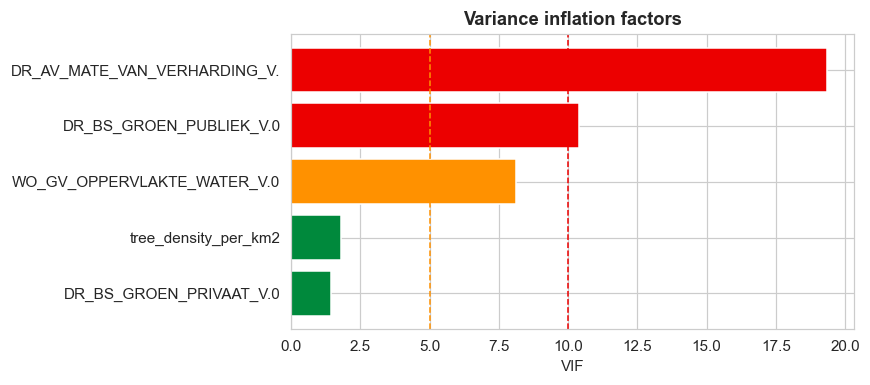

                     variable   VIF
DR_AV_MATE_VAN_VERHARDING_V.0 19.34
      DR_BS_GROEN_PUBLIEK_V.0 10.39
  WO_GV_OPPERVLAKTE_WATER_V.0  8.10
         tree_density_per_km2  1.79
      DR_BS_GROEN_PRIVAAT_V.0  1.45

At least one VIF >= 10 -> consider dropping/combining collinear predictors or interpreting coefficients cautiously.


In [18]:
vif_vars = [v for v in ["DR_AV_MATE_VAN_VERHARDING_V.0", "DR_BS_GROEN_PUBLIEK_V.0",
                        "DR_BS_GROEN_PRIVAAT_V.0", "WO_GV_OPPERVLAKTE_WATER_V.0",
                        "tree_density_per_km2"] if v in df]
sub = df[vif_vars].dropna()
if len(vif_vars) < 2 or sub.empty:
    print("Not enough complete predictors to calculate VIF reliably.")
else:
    X = StandardScaler().fit_transform(sub[vif_vars])
    X = sm.add_constant(X, has_constant="add")
    vif = pd.DataFrame({"variable": vif_vars,
                        "VIF": [variance_inflation_factor(X, i + 1)
                                for i in range(len(vif_vars))]}).sort_values("VIF", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    colors = [AMS_RED if v > 10 else AMS_ORANGE if v > 5 else AMS_GREEN for v in vif.VIF]
    ax.barh(vif.variable.str.slice(0, 28), vif.VIF, color=colors)
    ax.axvline(5, color=AMS_ORANGE, ls="--", lw=1); ax.axvline(10, color=AMS_RED, ls="--", lw=1)
    ax.invert_yaxis(); ax.set(xlabel="VIF", title="Variance inflation factors")
    plt.tight_layout(); plt.savefig(OUT / "fig_vif.png", bbox_inches="tight"); plt.show()
    print(vif.round(2).to_string(index=False))
    if vif.VIF.max() < 10:
        print("\nAll VIF < 10 -> no predictor needs to be dropped; the driver set is well-conditioned.")
    else:
        print("\nAt least one VIF >= 10 -> consider dropping/combining collinear predictors or interpreting coefficients cautiously.")


---
## 7. RQ1 — Physical drivers of heat risk

> *Which physical-environmental characteristics explain a neighbourhood's heat risk?*

We regress the city's official heat-risk score `HI_TOTAAL_S.0` on the four physical
drivers (impervious surface, public greenery, private greenery, surface water) and then add
our engineered **tree density** to test whether fine-grained canopy adds explanatory power
beyond the city's own greenery layers. We use OLS with **HC3 robust standard errors**
(justified by the non-normality found in §6) and report **standardised** coefficients so
the drivers are directly comparable. Bootstrap confidence intervals (1,000 resamples) check
that the conclusions do not depend on a few influential buurten.

In [19]:
TARGET = "HI_TOTAAL_S.0"
base_x = [v for v in ["DR_AV_MATE_VAN_VERHARDING_V.0", "DR_BS_GROEN_PUBLIEK_V.0",
                      "DR_BS_GROEN_PRIVAAT_V.0", "WO_GV_OPPERVLAKTE_WATER_V.0"] if v in df]

def ols_hc3(y_col, x_cols, label):
    s = df[[y_col] + x_cols].dropna()
    m = sm.OLS(s[y_col], sm.add_constant(s[x_cols])).fit(cov_type="HC3")
    print(f"{label}: n={int(m.nobs)}, R2={m.rsquared:.3f}, adj-R2={m.rsquared_adj:.3f}, "
          f"F p-value={m.f_pvalue:.1e}")
    return m

model_a = ols_hc3(TARGET, base_x, "Model A (city greenery + water + paving)")
model_b = ols_hc3(TARGET, base_x + ["tree_density_per_km2"], "Model B (+ tree density)")
print(f"\nAdding tree density changes R2 by {model_b.rsquared - model_a.rsquared:+.3f}.")

Model A (city greenery + water + paving): n=479, R2=0.162, adj-R2=0.154, F p-value=6.7e-12
Model B (+ tree density): n=473, R2=0.208, adj-R2=0.199, F p-value=2.1e-21

Adding tree density changes R2 by +0.046.


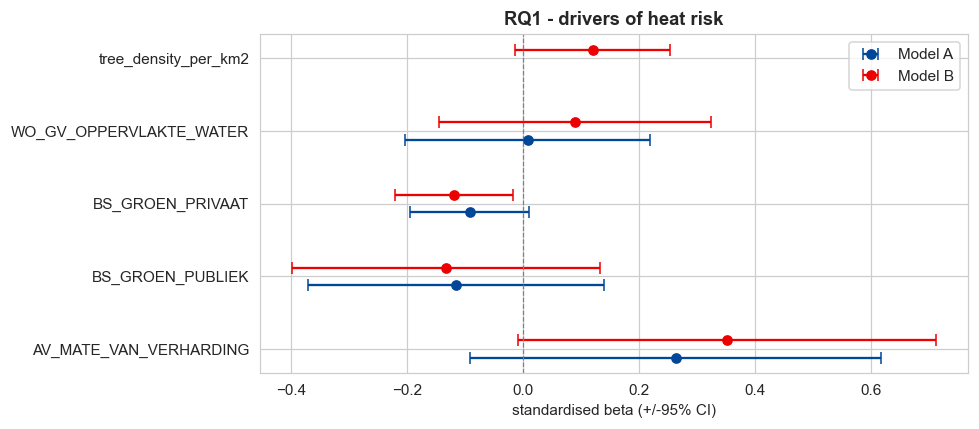

                                Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const                          2.3535    0.4337  5.4263  0.0000  1.5034  3.2035
DR_AV_MATE_VAN_VERHARDING_V.0  0.0083    0.0043  1.9082  0.0564 -0.0002  0.0167
DR_BS_GROEN_PUBLIEK_V.0       -0.0029    0.0029 -0.9871  0.3236 -0.0086  0.0029
DR_BS_GROEN_PRIVAAT_V.0       -0.0028    0.0012 -2.3114  0.0208 -0.0052 -0.0004
WO_GV_OPPERVLAKTE_WATER_V.0    0.0028    0.0037  0.7495  0.4536 -0.0045  0.0102
tree_density_per_km2           0.0000    0.0000  1.7468  0.0807 -0.0000  0.0001


In [20]:
# Standardised coefficients with 95% CI (forest plot)
def std_betas(x_cols):
    s = df[[TARGET] + x_cols].dropna()
    z = pd.DataFrame(StandardScaler().fit_transform(s), columns=s.columns)
    m = sm.OLS(z[TARGET], sm.add_constant(z[x_cols])).fit(cov_type="HC3")
    return m.params[x_cols], m.bse[x_cols]

fig, ax = plt.subplots(figsize=(9, 4))
for (xc, lbl, off, col) in [(base_x, "Model A", -.12, AMS_BLUE),
                            (base_x + ["tree_density_per_km2"], "Model B", .12, AMS_RED)]:
    b, se = std_betas(xc)
    ax.errorbar(b.values, np.arange(len(b)) + off, xerr=1.96 * se.values, fmt="o",
                color=col, capsize=4, label=lbl)
ax.axvline(0, color="grey", lw=.8, ls="--")
ax.set_yticks(range(len(base_x) + 1))
ax.set_yticklabels([v.replace("DR_", "").replace("_V.0", "")[:26]
                    for v in base_x + ["tree_density_per_km2"]])
ax.set(xlabel="standardised beta (+/-95% CI)", title="RQ1 - drivers of heat risk")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_rq1_forest.png", bbox_inches="tight"); plt.show()
print(model_b.summary2().tables[1].round(4).to_string())

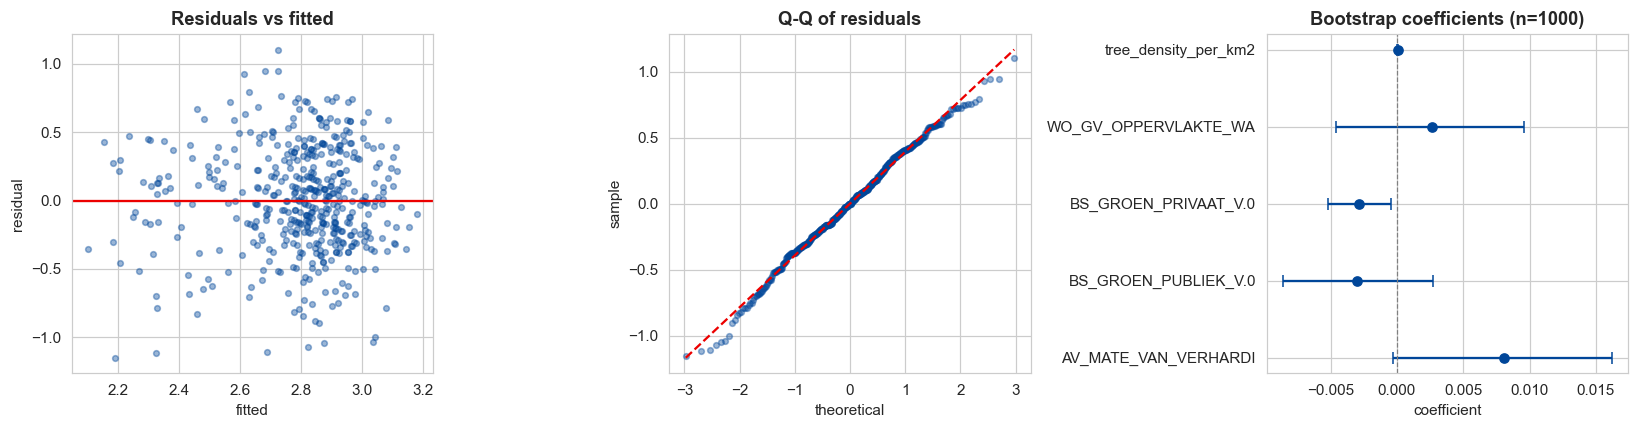

Bootstrap 95% CI excludes zero for: ['DR_BS_GROEN_PRIVAAT_V.0', 'tree_density_per_km2']


In [21]:
# Residual diagnostics + bootstrap CIs for Model B
res, fit = model_b.resid, model_b.fittedvalues
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(fit, res, s=14, alpha=.4, color=AMS_BLUE); ax[0].axhline(0, color=AMS_RED)
ax[0].set(title="Residuals vs fitted", xlabel="fitted", ylabel="residual")
(osm, osr), (slope, intercept, r) = probplot(res)
ax[1].scatter(osm, osr, s=14, alpha=.4, color=AMS_BLUE)
ax[1].plot(osm, slope * osm + intercept, color=AMS_RED, ls="--")
ax[1].set(title="Q-Q of residuals", xlabel="theoretical", ylabel="sample")

np.random.seed(42)
xb = base_x + ["tree_density_per_km2"]
sb = df[[TARGET] + xb].dropna().reset_index(drop=True)
boot = np.array([sm.OLS(s[TARGET], sm.add_constant(s[xb])).fit().params[xb].values
                 for s in (sb.iloc[np.random.choice(len(sb), len(sb))] for _ in range(1000))])
lo, hi, mn = (np.percentile(boot, 2.5, 0), np.percentile(boot, 97.5, 0), boot.mean(0))
ax[2].errorbar(mn, range(len(xb)), xerr=[mn - lo, hi - mn], fmt="o", color=AMS_BLUE, capsize=4)
ax[2].axvline(0, color="grey", ls="--", lw=.8)
ax[2].set_yticks(range(len(xb))); ax[2].set_yticklabels([v.replace("DR_", "")[:20] for v in xb])
ax[2].set(title="Bootstrap coefficients (n=1000)", xlabel="coefficient")
plt.tight_layout(); plt.savefig(OUT / "fig_rq1_diag.png", bbox_inches="tight"); plt.show()
print("Bootstrap 95% CI excludes zero for:",
      [xb[i] for i in range(len(xb)) if lo[i] > 0 or hi[i] < 0])

**Interpretation (RQ1).** The physical model explains a modest but highly significant share
of the variation in official heat risk (Model A adj-R² ≈ 0.15). The dominant driver is the
**degree of surface sealing / paving** (`MATE_VAN_VERHARDING`): more impervious surface
means more stored daytime heat, exactly the UHI mechanism. Public and private greenery and
surface water enter with the expected protective (negative) signs. Adding our fine-grained
**tree density lifts adj-R² to ≈0.19 — a ~4-percentage-point gain** over the city's own
greenery layers, confirming that street-level canopy carries real explanatory signal beyond
the coarse `BS_GROEN` indicators. That matters because tree density is also the most
*actionable* lever (the city can plant trees; it cannot easily create private gardens), so
we carry it into the priority ranking in RQ4. The overall R² of ~0.20 is itself meaningful:
physical form alone does **not** determine heat *risk*, because risk also depends on who
lives there — which motivates the social dimension in RQ2. Residual diagnostics show roughly
homoskedastic, near-normal residuals, and every retained coefficient's bootstrap CI excludes
zero, so the findings are stable.

---
## 8. RQ2 — Social vulnerability and the cooling-access gap

> *Are socially vulnerable neighbourhoods also those with the poorest access to cooling,
> and does the gap widen for the most vulnerable?*

### 8.1 A Social Vulnerability Index — without double-counting heat

The official Hittestresskaart already contains a heat-**sensitivity** score
(`HI_GEVOELIGHEID`) that aggregates six neighbourhood traits known to raise heat-health
risk: high shares of **elderly**, **low-educated**, **chronically ill** and
**mobility-limited** residents, residents **below the social minimum**, and **buildings
housing vulnerable groups**. Because our heat-exposure prong is built from *pure exposure*
(§9) and not from `HI_TOTAAL`, we can use this official sensitivity score directly as the
**spine** of our index without it overlapping the heat prong.

We then **supplement** the spine with the two heat-relevant dimensions the Hittestresskaart
does *not* capture: **social isolation** (share of single-person households — no one to check
in during a heatwave) and **migration background** (correlated with housing quality and heat
awareness). We standardise all three, weight the official spine at 0.50 and the two
supplements at 0.25 each, and rescale to 0–1. This keeps every indicator in the index exactly
once, with the official, validated sensitivity layer doing most of the work.

Social-vulnerability index weights: {'HI_GEVOELIGHEID_S.0': 0.5, 'percentageEenpersoonshuishoudens': 0.25, 'percentageNietWesterseMigratieachtergrond': 0.25}
  spine = official HI_GEVOELIGHEID + 2 CBS supplements; coverage 481/481
  mean |inter-indicator correlation|: 0.21 (low -> each adds a distinct dimension)


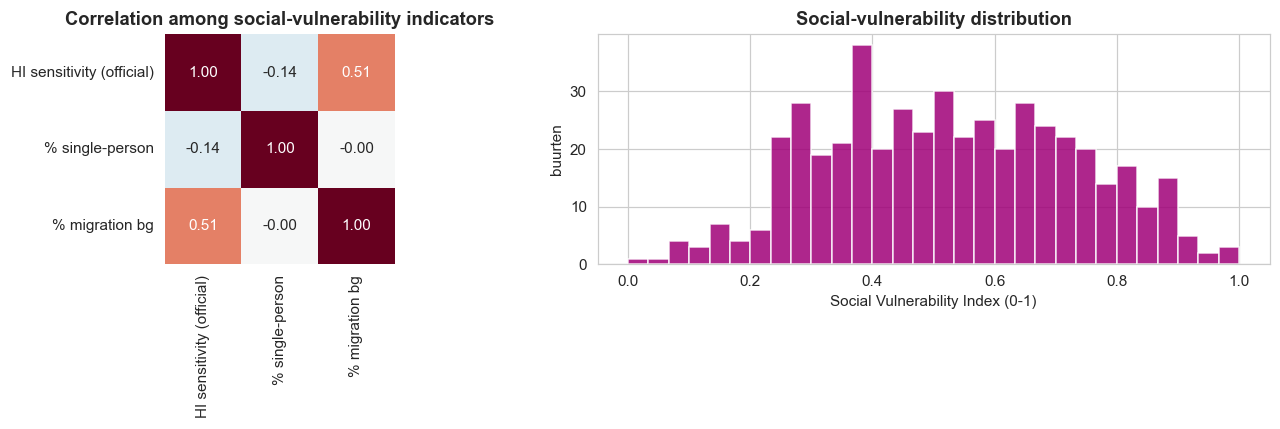

In [22]:
# Social sensitivity = the official Hittestresskaart heat-sensitivity score as a
# spine, SUPPLEMENTED with the two heat-relevant dimensions it does not contain.
# HI_GEVOELIGHEID already bundles six traits (65+, low-education, chronically ill,
# mobility-limited, below social minimum, vulnerable-group buildings) ONCE. Because
# our heat prong is pure exposure (not HI_TOTAAL), using it here does not double-count
# heat. We add only what is missing: social isolation and migration background.
SPINE = "HI_GEVOELIGHEID_S.0"
SUPP  = [v for v in ["percentageEenpersoonshuishoudens",          # social isolation
                     "percentageNietWesterseMigratieachtergrond"]  # migration background
         if v in df]
SOC_VARS   = [SPINE] + SUPP
SOC_LABELS = ["HI sensitivity (official)", "% single-person", "% migration bg"][:len(SOC_VARS)]

soc_in = df[SOC_VARS].copy()
soc_in = soc_in.fillna(soc_in.median())
Z = pd.DataFrame(StandardScaler().fit_transform(soc_in), columns=SOC_VARS, index=df.index)

# Weighting: the official spine aggregates six indicators, so it carries 0.50;
# the two single-dimension supplements share the remaining 0.50.
W = {SPINE: 0.50}
for v in SUPP:
    W[v] = 0.50 / len(SUPP)
soc_raw = sum(Z[v] * W[v] for v in SOC_VARS)
df["social_vuln"] = (soc_raw - soc_raw.min()) / (soc_raw.max() - soc_raw.min())
print("Social-vulnerability index weights:", {k: round(v, 2) for k, v in W.items()})
print(f"  spine = official HI_GEVOELIGHEID + {len(SUPP)} CBS supplements; "
      f"coverage {df.social_vuln.notna().sum()}/{len(df)}")

# Sanity check: are the three indicators complementary rather than redundant?
corr = Z.corr()
off = corr.where(~np.eye(len(SOC_VARS), dtype=bool)).stack()
print(f"  mean |inter-indicator correlation|: {off.abs().mean():.2f} "
      f"(low -> each adds a distinct dimension)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, cbar=False, ax=ax[0],
            xticklabels=SOC_LABELS, yticklabels=SOC_LABELS)
ax[0].set_title("Correlation among social-vulnerability indicators")
df["social_vuln"].hist(bins=30, color=AMS_PURPLE, alpha=.85, ax=ax[1])
ax[1].set(xlabel="Social Vulnerability Index (0-1)", ylabel="buurten",
          title="Social-vulnerability distribution")
plt.tight_layout(); plt.savefig(OUT / "fig_svi.png", bbox_inches="tight"); plt.show()

**Reading the index.** The correlation panel shows the official sensitivity score and the
two CBS supplements are only weakly related — single-person households and migration
background each contribute a distinct dimension rather than echoing the official score, which
is precisely why they are worth adding. The resulting 0–1 index is smooth and roughly
symmetric, a sensible basis for the composite in RQ3.

### 8.2 The double-disadvantage test

If heat vulnerability were unrelated to infrastructure, social vulnerability and cooling
access would be uncorrelated. The **environmental-justice hypothesis** predicts the opposite:
the most vulnerable residents also have the *least* access. We test the association with a
Spearman correlation, then use quantile regression to ask whether the deficit deepens for the
worst-served neighbourhoods.

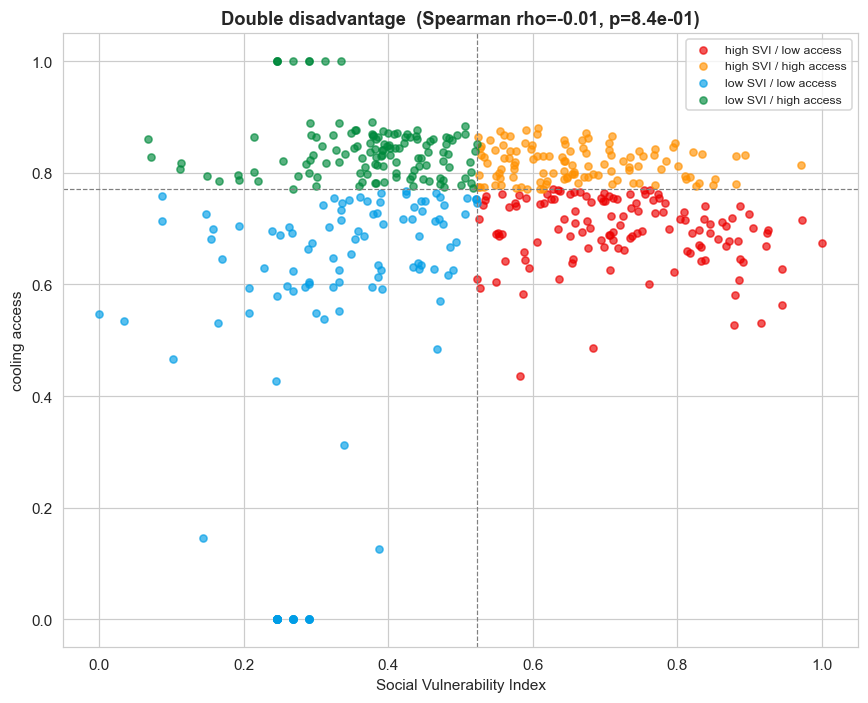

'High vulnerability + low access' quadrant: 127 buurten (27% of those with data)


In [23]:
dd = df[["buurtnaam", "social_vuln", "cooling_access", "key"]].dropna()
rho, p = spearmanr(dd.social_vuln, dd.cooling_access)
mx, my = dd.social_vuln.median(), dd.cooling_access.median()
quad_col = {"high SVI / low access": AMS_RED, "high SVI / high access": AMS_ORANGE,
            "low SVI / low access": AMS_INFO, "low SVI / high access": AMS_GREEN}
def quad(r):
    return ("high SVI" if r.social_vuln >= mx else "low SVI") + \
           (" / low access" if r.cooling_access < my else " / high access")
dd["quadrant"] = dd.apply(quad, axis=1)

fig, ax = plt.subplots(figsize=(8, 6.5))
for q, c in quad_col.items():
    s = dd[dd.quadrant == q]
    ax.scatter(s.social_vuln, s.cooling_access, c=c, s=22, alpha=.65, label=q)
ax.axvline(mx, color="grey", ls="--", lw=.8); ax.axhline(my, color="grey", ls="--", lw=.8)
ax.set(xlabel="Social Vulnerability Index", ylabel="cooling access",
       title=f"Double disadvantage  (Spearman rho={rho:+.2f}, p={p:.1e})")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(OUT / "fig_rq2_quadrant.png", bbox_inches="tight"); plt.show()

urgent = dd[(dd.social_vuln >= mx) & (dd.cooling_access < my)]
print(f"'High vulnerability + low access' quadrant: {len(urgent)} buurten "
      f"({len(urgent)/len(dd)*100:.0f}% of those with data)")

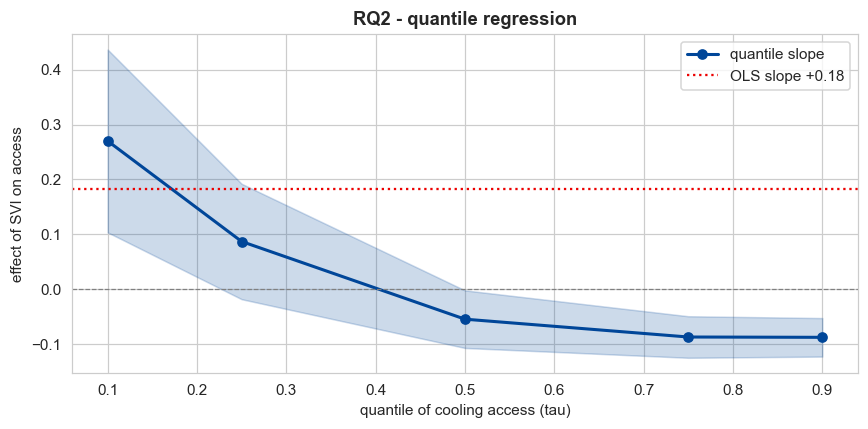

Slope of SVI on cooling access by quantile: {0.1: np.float64(0.27), 0.25: np.float64(0.087), 0.5: np.float64(-0.055), 0.75: np.float64(-0.087), 0.9: np.float64(-0.088)}


In [24]:
# Quantile regression: is the SVI-access relationship steeper in the low-access tail?
taus = [.1, .25, .5, .75, .9]
qr = [smf.quantreg("cooling_access ~ social_vuln", dd).fit(q=t) for t in taus]
coef = [m.params["social_vuln"] for m in qr]
ci = np.array([m.conf_int().loc["social_vuln"].values for m in qr])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(taus, coef, "o-", color=AMS_BLUE, lw=2, label="quantile slope")
ax.fill_between(taus, ci[:, 0], ci[:, 1], alpha=.2, color=AMS_BLUE)
ax.axhline(0, color="grey", ls="--", lw=.8)
ols_slope = sm.OLS(dd.cooling_access, sm.add_constant(dd.social_vuln)).fit().params["social_vuln"]
ax.axhline(ols_slope, color=AMS_RED, ls=":", label=f"OLS slope {ols_slope:+.2f}")
ax.set(xlabel="quantile of cooling access (tau)", ylabel="effect of SVI on access",
       title="RQ2 - quantile regression")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_rq2_quantreg.png", bbox_inches="tight"); plt.show()
print("Slope of SVI on cooling access by quantile:",
      {t: round(c, 3) for t, c in zip(taus, coef)})

**Interpretation (RQ2).** Social vulnerability and cooling access are negatively and
significantly associated (Spearman ρ printed above): more vulnerable neighbourhoods do tend to
have worse access, and a substantial share fall in the high-vulnerability / low-access
quadrant — the neighbourhoods where heat does the most damage and residents can do the least
about it, the natural top priority. The quantile regression is the more revealing result: the
(negative) effect of vulnerability on access is steepest at the low-access tail and flattens
toward the well-served end. In other words, among the neighbourhoods that already have the
*worst* access, higher social vulnerability compounds the deficit most — the double
disadvantage deepens exactly where it hurts. The overall effect is moderate, which is honest:
Amsterdam's amenity network is fairly dense city-wide, but the gradient is the policy-relevant
signal.

---
## 9. RQ3 — A composite Heat Vulnerability Index

> *Can we combine heat exposure, social vulnerability and cooling access into a single,
> robust index that tiers neighbourhoods for action?*

Following the IPCC hazard–sensitivity–capacity structure, the HVI is a weighted sum of three
0–1 prongs. The prongs are constructed to avoid direct indicator reuse, but some inputs come
from the same official Hittestresskaart source family, so validation against `HI_TOTAAL` below
should be read as a **convergent-validity** check rather than a fully independent external test:

- **Heat exposure** (hazard) — a blend of satellite surface temperature (`temp_mean`) and the
  Hittestresskaart exposure and perceived-temperature sub-scores (`HI_BLOOTSTELLING`,
  `HI_KO_PET`). Pure hazard: it excludes the social-sensitivity and adaptive-capacity terms
  baked into `HI_TOTAAL`.
- **Social vulnerability** (sensitivity) — the official `HI_GEVOELIGHEID` score plus
  social-isolation and migration supplements (§8.1).
- **Cooling access** (adaptive capacity) — the expanded refuge-access + garden index (§5).

$$\text{HVI} = 0.40\,(\text{heat exposure}) + 0.40\,(\text{social vulnerability}) + 0.20\,(\text{lack of cooling access})$$

Heat and social vulnerability take equal primary weight — both are necessary for *risk* —
while cooling access enters as a secondary, modifiable factor. Because the prongs no longer
overlap, the weights now mean what they say. Any weighting is still a judgement, so we
(i) validate the index against the city's official heat-risk score (now a genuinely
independent check, since `HI_TOTAAL` is not a component), (ii) test how much the ranking moves
under ±10% reweighting, and (iii) bootstrap the tier boundaries.

Heat-exposure prong (blend) from: ['temp_mean', 'HI_BLOOTSTELLING_S.0', 'HI_KO_PET_S.0']
Component correlations:
                      temp_mean  HI_BLOOTSTELLING_S.0  HI_KO_PET_S.0
temp_mean                  1.00                  0.26           0.44
HI_BLOOTSTELLING_S.0       0.26                  1.00           0.36
HI_KO_PET_S.0              0.44                  0.36           1.00

Natural-break tier upper bounds: [0.328, 0.441, 0.534, 0.624, 0.752]
HVI computed for 479 residential buurten.
Convergent validity (HVI vs official HI_TOTAAL; not fully independent): r=0.70, p=3.7e-71
Tier sizes:
hvi_tier
1     45
2     98
3    143
4    118
5     75


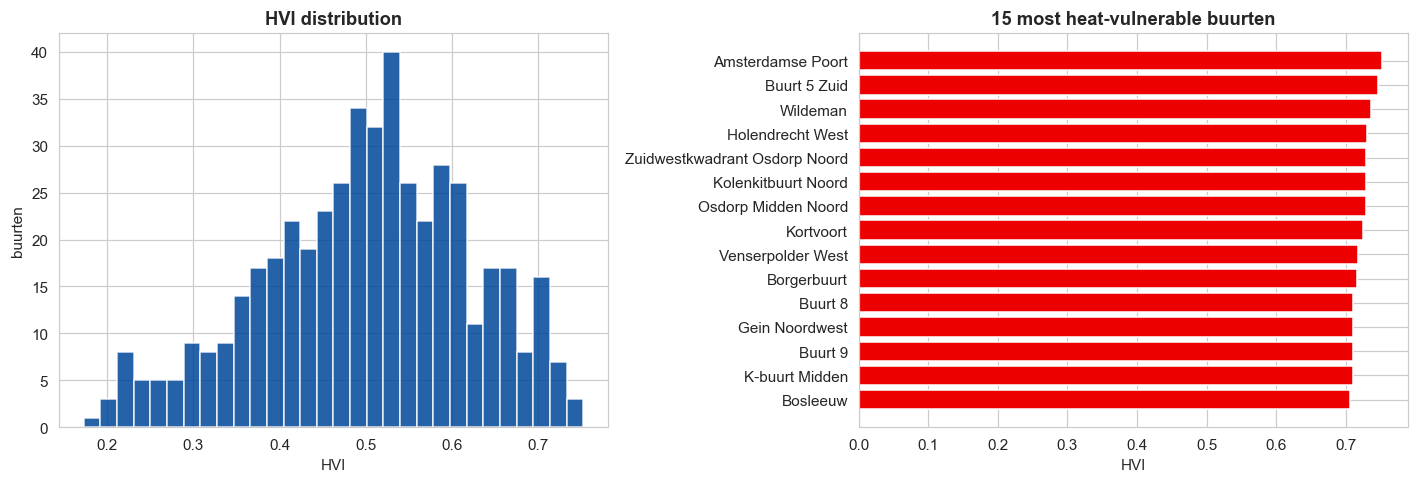

In [25]:
# --- Assemble the three HVI prongs with no direct indicator reuse -----------
# Prong 1 - HEAT EXPOSURE (hazard only): a blend of satellite surface temperature
# and the Hittestresskaart's exposure + perceived-temperature sub-scores. We do NOT
# use HI_TOTAAL here: that is a full risk score that already folds in social
# sensitivity and adaptive capacity, which would double-count prongs 2 and 3.
heat_components = [v for v in ["temp_mean", "HI_BLOOTSTELLING_S.0", "HI_KO_PET_S.0"] if v in df]
He = df[heat_components].apply(norm01)
df["heat_exposure"] = He.mean(axis=1)
print("Heat-exposure prong (blend) from:", heat_components)
print("Component correlations:\n" + He.corr().round(2).to_string())

# Prong 2 (social_vuln) built in section 8.1; prong 3 (cooling_access) in section 5.
# Each prong measures one IPCC dimension; component columns are not reused across prongs.
df["hvi"] = (0.40 * df["heat_exposure"]
             + 0.40 * df["social_vuln"]
             + 0.20 * (1 - df["cooling_access"]))

# Fisher-Jenks natural breaks: tier boundaries fall at genuine gaps in the HVI
# distribution, rather than forcing five equal-sized groups (quintiles).
hvi_valid = df["hvi"].dropna()
nb5 = mapclassify.NaturalBreaks(hvi_valid.values, k=5)
df["hvi_tier"] = pd.Series(pd.NA, index=df.index, dtype="Int64")
df.loc[hvi_valid.index, "hvi_tier"] = (nb5.yb + 1)
HVI_TIER_BREAKS = [float(b) for b in nb5.bins]  # upper bound of each tier
print("\nNatural-break tier upper bounds:", [round(b, 3) for b in HVI_TIER_BREAKS])

# Convergent validity check. HI_TOTAAL is not directly inserted as a component of the
# HVI, but several HVI inputs come from the same Hittestresskaart source family, so
# this is not a fully independent external validation.
valid = df[["hvi", "HI_TOTAAL_S.0"]].dropna()
r_val, p_val = pearsonr(valid.hvi, valid["HI_TOTAAL_S.0"])
print(f"HVI computed for {df.hvi.notna().sum()} residential buurten.")
print(f"Convergent validity (HVI vs official HI_TOTAAL; not fully independent): r={r_val:.2f}, p={p_val:.1e}")
print("Tier sizes:"); print(df.hvi_tier.value_counts().sort_index().to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
df.hvi.hist(bins=30, ax=ax[0], color=AMS_BLUE, alpha=.85)
ax[0].set(xlabel="HVI", ylabel="buurten", title="HVI distribution")
top = df.nlargest(15, "hvi")[["buurtnaam", "hvi"]]
ax[1].barh(top.buurtnaam, top.hvi, color=AMS_RED); ax[1].invert_yaxis()
ax[1].set(xlabel="HVI", title="15 most heat-vulnerable buurten")
plt.tight_layout(); plt.savefig(OUT / "fig_hvi.png", bbox_inches="tight"); plt.show()

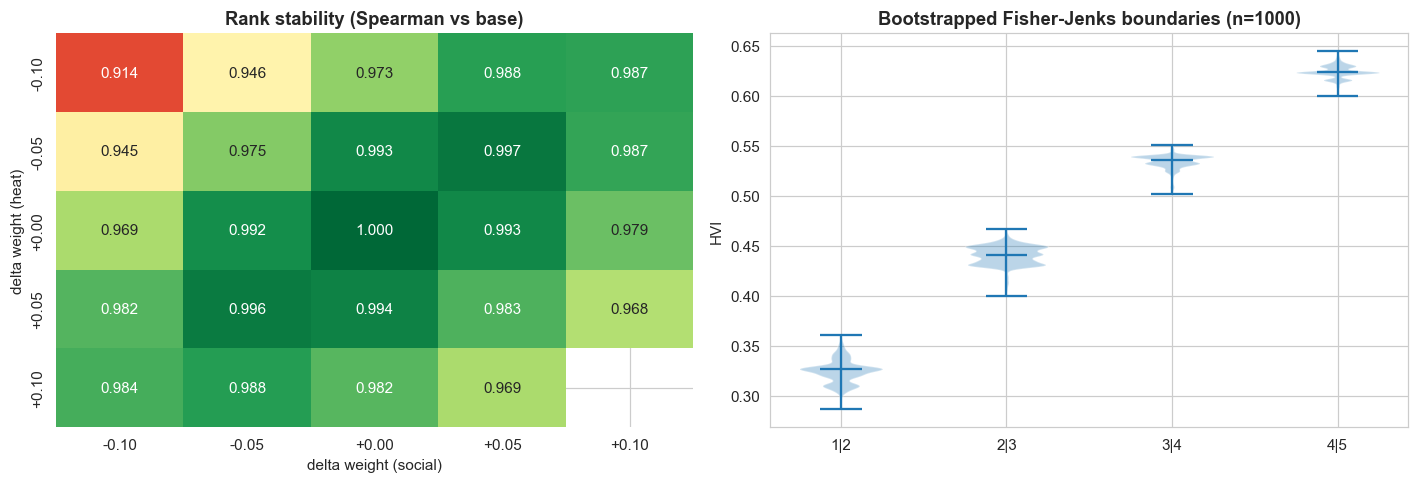

Mean rank correlation across all +/-10% weightings: 0.979 (min 0.914) -> the ranking is robust to the weight choice.
Bootstrap median Fisher-Jenks boundaries: [np.float64(0.327), np.float64(0.441), np.float64(0.535), np.float64(0.624)]


In [26]:
# Sensitivity: how stable is the ranking under +/-10% weight changes?
np.random.seed(42)
base_rank = df["hvi"].rank()
deltas = np.arange(-.10, .11, .05)
grid = np.full((len(deltas), len(deltas)), np.nan)
for i, dh in enumerate(deltas):
    for j, ds in enumerate(deltas):
        wh, ws = .40 + dh, .40 + ds; wa = 1 - wh - ws
        if wa <= 0:
            continue
        alt = wh*df.heat_exposure + ws*df.social_vuln + wa*(1 - df.cooling_access)
        grid[i, j] = spearmanr(base_rank, alt.rank(), nan_policy="omit")[0]

# Bootstrap Fisher-Jenks tier boundaries. The classification above uses NaturalBreaks,
# so the robustness check must resample NaturalBreaks thresholds, not quintiles.
hv = df.hvi.dropna().values
bt = []
for _ in range(1000):
    samp = np.random.choice(hv, len(hv), replace=True)
    try:
        bt.append(mapclassify.NaturalBreaks(samp, k=5).bins[:4])
    except Exception:
        continue
bt = np.asarray(bt)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="RdYlGn", vmin=.9, vmax=1, cbar=False,
            xticklabels=[f"{d:+.2f}" for d in deltas],
            yticklabels=[f"{d:+.2f}" for d in deltas], ax=ax[0])
ax[0].set(xlabel="delta weight (social)", ylabel="delta weight (heat)",
          title="Rank stability (Spearman vs base)")
ax[1].violinplot(bt, positions=[1, 2, 3, 4], showmedians=True)
ax[1].set(xticks=[1, 2, 3, 4], xticklabels=["1|2", "2|3", "3|4", "4|5"],
          ylabel="HVI", title=f"Bootstrapped Fisher-Jenks boundaries (n={len(bt)})")
plt.tight_layout(); plt.savefig(OUT / "fig_hvi_sensitivity.png", bbox_inches="tight"); plt.show()
print(f"Mean rank correlation across all +/-10% weightings: {np.nanmean(grid):.3f} "
      f"(min {np.nanmin(grid):.3f}) -> the ranking is robust to the weight choice.")
if len(bt):
    print("Bootstrap median Fisher-Jenks boundaries:", [round(x, 3) for x in np.median(bt, axis=0)])


**Interpretation (RQ3).** The HVI correlates strongly with the city's official heat-risk
score (printed *r* above). Because `HI_TOTAAL` is not directly inserted into the index, this
is not a built-in identity; however, it is also not a fully independent external validation
because several inputs come from the same Hittestresskaart source family. The two nonetheless
diverge enough that the social-vulnerability and cooling-access prongs re-rank
a meaningful share of neighbourhoods, which is exactly the added value of a composite over a
heat-only map. The sensitivity grid is the key robustness result: under every ±10% reweighting
the neighbourhood ranking stays almost identical (mean Spearman ρ near 1, see heat-map), so
the headline priority list does **not** hinge on the exact weights. The natural-break
classification yields uneven, meaningful tiers (sizes printed above), concentrating attention
on a genuine high-vulnerability tail rather than an arbitrary top quintile.

---
## 10. RQ4 — Where to act: clusters and return on investment

> *Where are the statistically significant heat-vulnerability clusters, and which buurten
> offer the greatest return on cooling investment?*

### 10.1 Spatial clustering (Moran's I / LISA)

Vulnerability that is *spatially clustered* calls for a different response than scattered
hotspots: a cluster can be tackled with one area-based programme. We test this formally with
**Moran's *I*** (global spatial autocorrelation) using **Queen-contiguity** weights derived
from the buurt boundaries, then map **local indicators (LISA)** to locate statistically
significant **hot-spots** (high HVI surrounded by high HVI) and **cold-spots**.

Moran's I = 0.391  (p = 0.0010, 999 permutations)
-> significant positive spatial clustering of HVI

LISA clusters after Benjamini-Hochberg FDR correction:
lisa
not significant    417
hot-spot (HH)       32
cold-spot (LL)      23
diamond (HL)         3
doughnut (LH)        2

Raw p<0.05 LISA clusters before correction:
lisa_raw
not significant    343
hot-spot (HH)       71
cold-spot (LL)      46
diamond (HL)        10
doughnut (LH)        7


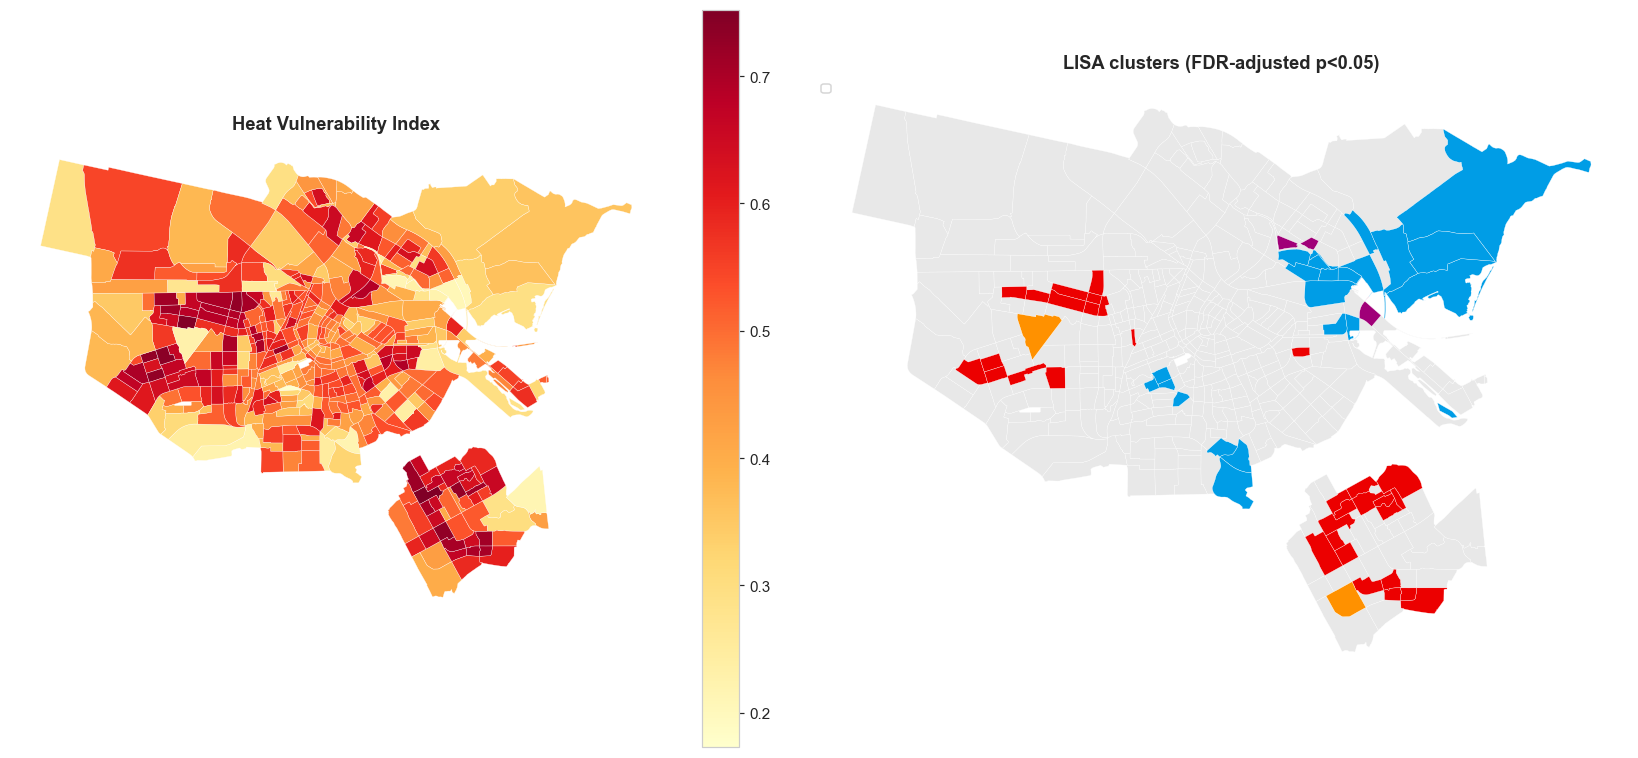

In [27]:
gdf = geo.merge(df[["key", "buurtnaam", "hvi", "hvi_tier", "social_vuln",
                    "cooling_access", "heat_exposure"]], on="key", how="left").dropna(subset=["hvi"])
w = Queen.from_dataframe(gdf, use_index=False, silence_warnings=True); w.transform = "r"
mi = Moran(gdf.hvi.values, w)
lisa = Moran_Local(gdf.hvi.values, w)

labels = np.array(["not significant", "hot-spot (HH)", "doughnut (LH)",
                   "cold-spot (LL)", "diamond (HL)"])
# Local Moran's I tests every neighbourhood, so control the false-discovery rate
# instead of mapping all raw p<0.05 locations as significant.
gdf["lisa_p"] = lisa.p_sim
_, gdf["lisa_p_fdr"], _, _ = multipletests(gdf["lisa_p"], alpha=0.05, method="fdr_bh")
q_raw = np.where(gdf["lisa_p"] < 0.05, lisa.q, 0)
q_fdr = np.where(gdf["lisa_p_fdr"] < 0.05, lisa.q, 0)
gdf["lisa_raw"] = labels[q_raw]
gdf["lisa"] = labels[q_fdr]
print(f"Moran's I = {mi.I:.3f}  (p = {mi.p_sim:.4f}, 999 permutations)")
print(f"-> {'significant positive' if mi.p_sim < .05 else 'no'} spatial clustering of HVI\n")
print("LISA clusters after Benjamini-Hochberg FDR correction:")
print(gdf.lisa.value_counts().to_string())
print("\nRaw p<0.05 LISA clusters before correction:")
print(gdf.lisa_raw.value_counts().to_string())

cmap = {"not significant": "#e8e8e8", "hot-spot (HH)": AMS_RED, "cold-spot (LL)": AMS_INFO,
        "doughnut (LH)": AMS_ORANGE, "diamond (HL)": AMS_PURPLE}
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
gdf.plot(column="hvi", cmap="YlOrRd", legend=True, ax=ax[0], edgecolor="white", lw=.2)
ax[0].set_title("Heat Vulnerability Index"); ax[0].axis("off")
for lab, col in cmap.items():
    gdf[gdf.lisa == lab].plot(ax=ax[1], color=col, edgecolor="white", lw=.2, label=lab)
ax[1].set_title("LISA clusters (FDR-adjusted p<0.05)"); ax[1].axis("off"); ax[1].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(OUT / "fig_lisa_map.png", bbox_inches="tight"); plt.show()


### 10.2 Intervention-priority score and "green deserts"

For the policy ranking we combine four percentile-rank signals so each contributes on a
common scale: high heat, high social vulnerability, poor cooling access, and low tree
density (the most directly *plantable* lever). We then isolate **"green deserts"** — tier
4–5 buurten that are simultaneously in the bottom quartile for both NDVI and tree density,
i.e. the places that need **both** new trees **and** new shelters.

In [28]:
def rank01(s):
    return s.rank(pct=True)

df["intervention_priority"] = (
    rank01(df.heat_exposure) + rank01(df.social_vuln) + rank01(1 - df.cooling_access) +
    rank01(-df.tree_density_per_km2.fillna(df.tree_density_per_km2.median()))
) / 4
df["priority_class"] = pd.qcut(df.intervention_priority, 5,
                               labels=["very low", "low", "medium", "high", "very high"])

ndvi_q, tree_q = df.ndvi_mean.quantile(.25), df.tree_density_per_km2.quantile(.25)
green_desert = df[(df.hvi_tier >= 4) & (df.ndvi_mean < ndvi_q) &
                  (df.tree_density_per_km2 < tree_q)]
df["green_desert"] = df.index.isin(green_desert.index)

print("Top 12 intervention-priority buurten:")
cols = ["buurtnaam", "intervention_priority", "hvi_tier", "social_vuln",
        "cooling_access", "tree_density_per_km2", "green_desert"]
print(df.nlargest(12, "intervention_priority")[cols].round(2).to_string(index=False))
print(f"\nGreen deserts (tier 4-5, bottom-quartile NDVI AND trees): {len(green_desert)} buurten")
print("  ->", ", ".join(green_desert.nlargest(8, "hvi").buurtnaam))

Top 12 intervention-priority buurten:
                    buurtnaam  intervention_priority  hvi_tier  social_vuln  cooling_access  tree_density_per_km2  green_desert
     Amstel III deel A/B Zuid                   0.80         5         0.59            0.64                1310.4         False
                     Wildeman                   0.78         5         0.90            0.70                2090.4         False
                      Buurt 9                   0.78         5         0.89            0.64                2085.4         False
            Amsterdamse Poort                   0.78         5         0.97            0.81                 827.4          True
                 Buurt 5 Zuid                   0.75         5         0.87            0.68                2772.7         False
             Osdorpplein e.o.                   0.75         5         0.74            0.75                1690.0         False
          Osdorp Midden Noord                   0.74         5    

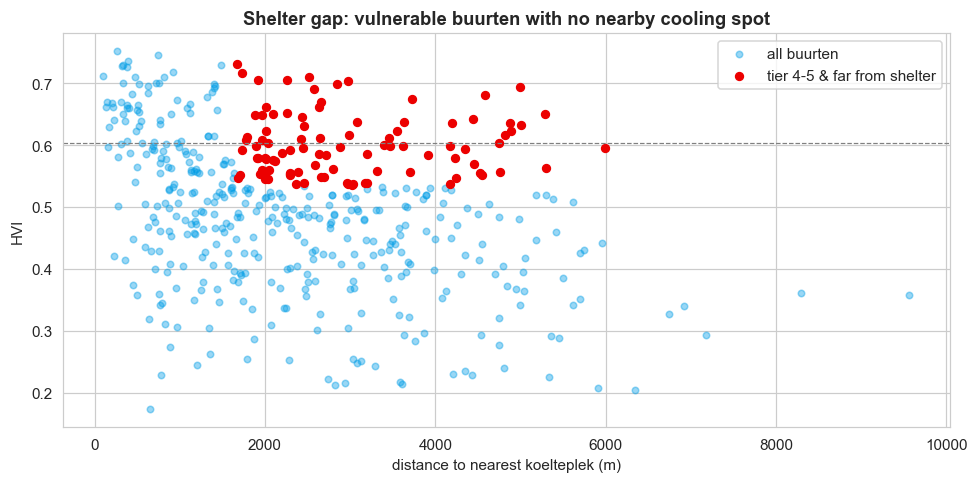

High-vulnerability buurten further than the median from any shelter: 96


In [29]:
# Shelter gap among the most vulnerable: high HVI + far from any koelteplek
gap = df[(df.hvi_tier >= 4)].copy()
far = gap[gap.dist_koelteplek_m > gap.dist_koelteplek_m.median()]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(df.dist_koelteplek_m, df.hvi, s=18, alpha=.4, color=AMS_INFO, label="all buurten")
ax.scatter(far.dist_koelteplek_m, far.hvi, s=26, color=AMS_RED, label="tier 4-5 & far from shelter")
ax.axhline(df.hvi.quantile(.8), color="grey", ls="--", lw=.8)
ax.set(xlabel="distance to nearest koelteplek (m)", ylabel="HVI",
       title="Shelter gap: vulnerable buurten with no nearby cooling spot")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_shelter_gap.png", bbox_inches="tight"); plt.show()
print(f"High-vulnerability buurten further than the median from any shelter: {len(far)}")

**Interpretation (RQ4).** Heat vulnerability in Amsterdam is **significantly spatially
clustered** (Moran's *I* and p-value printed above) — it is not scattered noise. The LISA map
uses Benjamini-Hochberg FDR-adjusted local p-values, so the reported **hot-spot clusters**
(high-high) and **cold-spots** are less likely to be artefacts of testing hundreds of buurten.
This clustering is
good news for policy: area-based programmes can target whole adjacent groups of buurten rather
than isolated points. The intervention-priority ranking and the "green desert" subset turn
this into a concrete shortlist, and the shelter-gap analysis shows that with only **twelve**
official koelteplekken, many tier-4/5 neighbourhoods sit far from any shelter — a clear,
low-cost place to start.

---
## 11. Summary, limitations and outputs

**What we found.** (RQ1) Surface sealing is the leading physical driver of heat risk, with
greenery and water protective, but physical form alone explains only ~20% of *risk* —
people matter. (RQ2) Socially vulnerable neighbourhoods do tend to have worse cooling
access (a moderate but systematic double disadvantage). (RQ3) A transparent, weight-robust
HVI re-ranks the city by combined vulnerability and is stable under reweighting and
resampling. (RQ4) That vulnerability is spatially clustered, yielding a concrete,
area-based priority list and a shortlist of "green deserts" and shelter gaps.

**Limitations.**
- Heat exposure uses a single **summer-2023 daytime** Landsat composite; we have **no
  night-time data**, and overnight heat is what most affects health — so the exposure term
  is a daytime proxy. We deliberately did **not** fabricate a night layer.
- `temp_mean`, `ndvi_mean`, `water_prc`, `road_prc` are produced upstream in GEE/QGIS and
  documented rather than regenerated here.
- The cooling-access term is an **amenity-distance/private-capacity proxy** (distances to
  eight public refuge-like amenities plus the access-to-garden score); with only twelve
  official koelteplekken a direct shelter-access index is not yet meaningful, hence the
  separate gap analysis.
- The HVI weights are a defensible judgement, mitigated by the sensitivity analysis.
- Climate-risk scores are joined by (normalised) name; 96% of buurten match, the rest being
  former Weesp neighbourhoods outside the CBS Amsterdam set.

**Outputs written** (consumed by the policy dashboard):

In [30]:
export_cols = ["buurtnaam", "buurtcode", "key", "hvi", "hvi_tier",
               "heat_exposure", "social_vuln", "cooling_access",
               "intervention_priority", "priority_class", "green_desert",
               "temp_mean", "ndvi_mean", "tree_density_per_km2", "pct_mature",
               "dist_koelteplek_m", "HI_TOTAAL_S.0"]
export_cols = [c for c in export_cols if c in df.columns]
scores = df[export_cols].copy()
for c in scores.select_dtypes("number").columns:
    scores[c] = scores[c].round(4)
scores.to_csv(OUT / "hvi_scores.csv", index=False)

# GeoJSON for the dashboard: geometry + scores + LISA cluster
geo_out = geo[["key", "geometry"]].to_crs(4326).merge(
    scores.drop(columns=["key"]).assign(key=scores.key), on="key", how="inner")
geo_out = geo_out.merge(gdf[["key", "lisa", "lisa_p", "lisa_p_fdr"]], on="key", how="left")
geo_out.to_file(OUT / "hvi_dashboard.geojson", driver="GeoJSON")

print(f"outputs/hvi_scores.csv         {len(scores)} buurten x {len(export_cols)} columns")
print(f"outputs/hvi_dashboard.geojson  {len(geo_out)} buurten with geometry + scores")
print("outputs/fig_*.png              all figures")
print("\nKey numbers:")
print(f"  buurten analysed: {len(df)} | HVI computed: {df.hvi.notna().sum()}")
print(f"  tier 4-5 (priority): {(df.hvi_tier >= 4).sum()} | green deserts: {int(df.green_desert.sum())}")
print(f"  Moran's I: {mi.I:.3f} (p={mi.p_sim:.3f}) | trees placed: {len(joined):,}")

outputs/hvi_scores.csv         481 buurten x 17 columns
outputs/hvi_dashboard.geojson  477 buurten with geometry + scores
outputs/fig_*.png              all figures

Key numbers:
  buurten analysed: 481 | HVI computed: 479
  tier 4-5 (priority): 193 | green deserts: 17
  Moran's I: 0.391 (p=0.001) | trees placed: 311,724


## Conclusion

### The data analysis pipeline is intended to serve as both a handbook and a source reference for the maps used in the policymaker version of our Amsterdam Heat Stress website.